# Original Architecture

This notebook contains the complete training record for the original simple encoder-decoder architecture and explains why it did not produce a usable clean baseline. The final comparison is computed directly from the generated CSV logs. Success is defined as validation **BER** below `0.2` with acceptable image quality. Test split is not used in this notebook, since training did not succeed.

In [ ]:
import json
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.data import get_dataloaders
from src.train import TrainConfig, fit, run_training, train_one_epoch, validate
from src.utils import SEED, set_seed

set_seed()
EVALUATION_DEVICE = torch.device("cpu")

print(f"Seed: {SEED}")
print(f"Evaluation device: {EVALUATION_DEVICE}")

Seed: 95
Evaluation device: cpu


## Data Preparation

We used the following **split**: 4,000 training images, 500 validation images and 500 reserved test images. Images are proportionally resized to `128x128` and padded, while the content mask identifies the actual image area.

In [ ]:
DATA_DIR = PROJECT_ROOT / "data"
SPLITS_FILE = DATA_DIR / "splits.json"

with SPLITS_FILE.open("r", encoding="utf-8") as split_file:
    splits = json.load(split_file)

train_loader, val_loader, _ = get_dataloaders(DATA_DIR, SPLITS_FILE, batch_size=16, num_workers=0)

sample_images, sample_masks = next(iter(val_loader))

print(f"Train images: {len(splits['train'])}")
print(f"Validation images: {len(splits['val'])}")
print(f"Reserved test images: {len(splits['test'])}")
print(f"Image batch shape: {tuple(sample_images.shape)}")
print(f"Mask batch shape: {tuple(sample_masks.shape)}")

Train images: 4000
Validation images: 500
Reserved test images: 500
Image batch shape: (16, 3, 128, 128)
Mask batch shape: (16, 1, 128, 128)


## Architecture

### Encoder

The message is spatially expanded and immediately concatenated with the RGB image. Three `Conv2d-ReLU` layers then directly produce an image residual. In the constrained 16-bit experiment, the residual was limited with `0.03 * tanh(raw_residual)` and applied only inside the content mask.

### Decoder

The decoder uses three `Conv2d-ReLU-MaxPool` blocks. Resolution is reduced as `128x128 -> 64x64 -> 32x32 -> 16x16`, followed by global average pooling and a linear output layer. The content mask was not used during decoding.

In [ ]:
class OriginalWatermarkEncoder(nn.Module):
    def __init__(self, message_length=16, image_channels=3, feature_channels=(64, 64, 32), max_delta=0.03):
        super().__init__()
        self.message_length = message_length
        self.max_delta = max_delta

        channels1, channels2, channels3 = feature_channels
        self.conv1 = nn.Conv2d(image_channels + message_length, channels1, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(channels1, channels2, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv2d(channels2, channels3, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.conv_out = nn.Conv2d(channels3, image_channels, kernel_size=3, padding=1)

    def forward(self, images, messages, masks):
        height, width = images.shape[-2:]
        expanded_messages = messages.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, height, width)
        features = torch.cat([images, expanded_messages], dim=1)

        features = self.relu1(self.conv1(features))
        features = self.relu2(self.conv2(features))
        features = self.relu3(self.conv3(features))

        residual = self.conv_out(features)
        if self.max_delta is not None:
            residual = self.max_delta * torch.tanh(residual)

        return torch.clamp(images + residual * masks, 0.0, 1.0)

In [ ]:
class OriginalWatermarkDecoder(nn.Module):
    def __init__(self, message_length=16, feature_channels=(32, 64, 128)):
        super().__init__()
        channels1, channels2, channels3 = feature_channels

        self.conv1 = nn.Conv2d(3, channels1, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(channels1, channels2, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(channels2, channels3, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.fc = nn.Linear(channels3, message_length)

    def forward(self, images, masks=None):
        features = self.pool1(self.relu1(self.conv1(images)))
        features = self.pool2(self.relu2(self.conv2(features)))
        features = self.pool3(self.relu3(self.conv3(features)))
        features = features.mean(dim=(2, 3))
        return self.fc(features)

In [ ]:
encoder = OriginalWatermarkEncoder()
decoder = OriginalWatermarkDecoder()

images = sample_images[:2]
masks = sample_masks[:2]
messages = torch.randint(0, 2, (len(images), 16), generator=torch.Generator().manual_seed(SEED), dtype=torch.float32)

with torch.no_grad():
    watermarked = encoder(images, messages, masks)
    logits = decoder(watermarked)

encoder_parameters = sum(parameter.numel() for parameter in encoder.parameters())
decoder_parameters = sum(parameter.numel() for parameter in decoder.parameters())

print(f"Watermarked images: {tuple(watermarked.shape)}")
print(f"Decoder logits: {tuple(logits.shape)}")
print(f"Encoder parameters: {encoder_parameters:,}")
print(f"Decoder parameters: {decoder_parameters:,}")
print(f"Total parameters: {encoder_parameters + decoder_parameters:,}")

Watermarked images: (2, 3, 128, 128)
Decoder logits: (2, 16)
Encoder parameters: 67,267
Decoder parameters: 95,312
Total parameters: 162,579


## Training the model

We will train the model on several configurations and datasets. Each configuration is followed by its saved epoch output, summary and training curves.

The experiments progress from the small set check through message-only training, image-loss weighting, capacity changes, bounded 16-bit models and the average-pooling check. No noise attacks are used in this stage.

### Helper Functions

We will first define functions for preparing a smaller split and for loading, summarizing and visualizing the results for each run.

In [9]:
def make_subset_splits_file(source_splits_file, output_splits_file, n_train=16, n_val=4, n_test=4):
    """Create a small split with the first `n` images of each split from an existing one."""

    with open(source_splits_file, "r") as f:
        splits = json.load(f)

    subset = {
        "train": splits["train"][:n_train],
        "val": splits["val"][:n_val],
        "test": splits["test"][:n_test],
    }

    output_splits_file = Path(output_splits_file)
    output_splits_file.parent.mkdir(parents=True, exist_ok=True)
    with output_splits_file.open("w") as f:
        json.dump(subset, f, indent=2)

    return output_splits_file

In [ ]:
def clear_training_log(log_path):
    """Remove an old log before starting a fresh experiment."""

    log_path = Path(log_path)
    if log_path.exists():
        log_path.unlink()


def load_training_log(log_path):
    """Load a log file written by training function into a pandas DataFrame."""

    log_path = Path(log_path)
    if not log_path.exists():
        raise FileNotFoundError(f"No log file found at {log_path}")

    return pd.read_csv(log_path)


def summarize_training_log(df, name="", show_validation=True):
    """Print the best and last epoch statistics."""

    selection_metric = "val_loss" if show_validation else "train_loss"
    best_row = df.loc[df[selection_metric].idxmin()]
    last_row = df.iloc[-1]

    title = f"Summary for {name}" if name else "Summary"
    print(title)
    print("-" * len(title))
    print(f"Epochs run: {int(last_row['epoch'])}")
    if "epoch_seconds" in df.columns:
        print(f"Training time: {df['epoch_seconds'].sum() / 60:.1f} minutes")
    print(
        f"Best result by {selection_metric}: "
        f"epoch {int(best_row['epoch'])}"
    )
    print(
        f"  train: loss={best_row['train_loss']:.4f}, "
        f"BER={best_row['train_ber']:.4f}, "
        f"exact_accuracy={best_row['train_exact_accuracy']:.4f}, "
        f"PSNR={best_row['train_psnr']:.2f}"
    )
    if show_validation:
        print(
            f"  val: loss={best_row['val_loss']:.4f}, "
            f"BER={best_row['val_ber']:.4f}, "
            f"exact_accuracy={best_row['val_exact_accuracy']:.4f}, "
            f"PSNR={best_row['val_psnr']:.2f}"
        )
    print("Last epoch:")
    print(
        f"  train: loss={last_row['train_loss']:.4f}, "
        f"BER={last_row['train_ber']:.4f}, "
        f"exact_accuracy={last_row['train_exact_accuracy']:.4f}, "
        f"PSNR={last_row['train_psnr']:.2f}"
    )
    if show_validation:
        print(
            f"  val: loss={last_row['val_loss']:.4f}, "
            f"BER={last_row['val_ber']:.4f}, "
            f"exact_accuracy={last_row['val_exact_accuracy']:.4f}, "
            f"PSNR={last_row['val_psnr']:.2f}"
        )

    return best_row, last_row


def plot_training_log(df, name="", metrics=("loss", "message_loss", "image_loss", "ber", "exact_accuracy", "psnr"), show_validation=True):
    """Plot metric curves from a training log."""

    metrics = [m for m in metrics if f"train_{m}" in df.columns or f"val_{m}" in df.columns]
    n_cols = 3
    n_rows = -(-len(metrics) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

    for i, metric in enumerate(metrics):
        ax = axes[i // n_cols][i % n_cols]
        if f"train_{metric}" in df.columns:
            ax.plot(df["epoch"], df[f"train_{metric}"], label="train")
        if show_validation and f"val_{metric}" in df.columns:
            ax.plot(df["epoch"], df[f"val_{metric}"], label="val")
        ax.set_xlabel("epoch")
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend()

    for j in range(len(metrics), n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis("off")

    fig.suptitle(name)
    fig.tight_layout()
    plt.show()


def analyze_run(log_path, name="", show_validation=True):
    """Load, summarize and plot a training run log file."""

    df = load_training_log(log_path)
    summarize_training_log(df, name=name, show_validation=show_validation)
    plot_training_log(df, name=name, show_validation=show_validation)
    return df

## Small set overfitting check

The goal here is to train the model on eight images with fixed messages and no image-quality penalty in order to verify that the encoder-decoder pipeline can fully memorize a small training set before running full-dataset experiments.

In [ ]:
SMALL_SPLIT_FILE = make_subset_splits_file(SPLITS_FILE, DATA_DIR / "splits_small.json", n_train=8, n_val=0, n_test=0)
SMALL_SPLIT_FILE

WindowsPath('../data/splits_small.json')

Epoch 1/200 | train_loss=0.6928 | train_BER=0.4805 | train_exact=0.0000 | 0.2s
Epoch 20/200 | train_loss=0.5967 | train_BER=0.3398 | train_exact=0.0000 | 0.2s
Epoch 40/200 | train_loss=0.5007 | train_BER=0.2734 | train_exact=0.1250 | 0.2s
Epoch 60/200 | train_loss=0.3935 | train_BER=0.1953 | train_exact=0.1250 | 0.2s
Epoch 80/200 | train_loss=0.2698 | train_BER=0.1250 | train_exact=0.2500 | 0.2s
Epoch 100/200 | train_loss=0.1196 | train_BER=0.0469 | train_exact=0.3750 | 0.2s
Epoch 120/200 | train_loss=0.0411 | train_BER=0.0039 | train_exact=0.8750 | 0.2s
Epoch 140/200 | train_loss=0.0912 | train_BER=0.0273 | train_exact=0.5000 | 0.2s
Epoch 160/200 | train_loss=0.0149 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Epoch 180/200 | train_loss=0.0050 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Epoch 200/200 | train_loss=0.0022 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Training time: 0.6 minutes
Summary for Tiny overfit test
-----------------------------
Epochs run: 200
Training tim

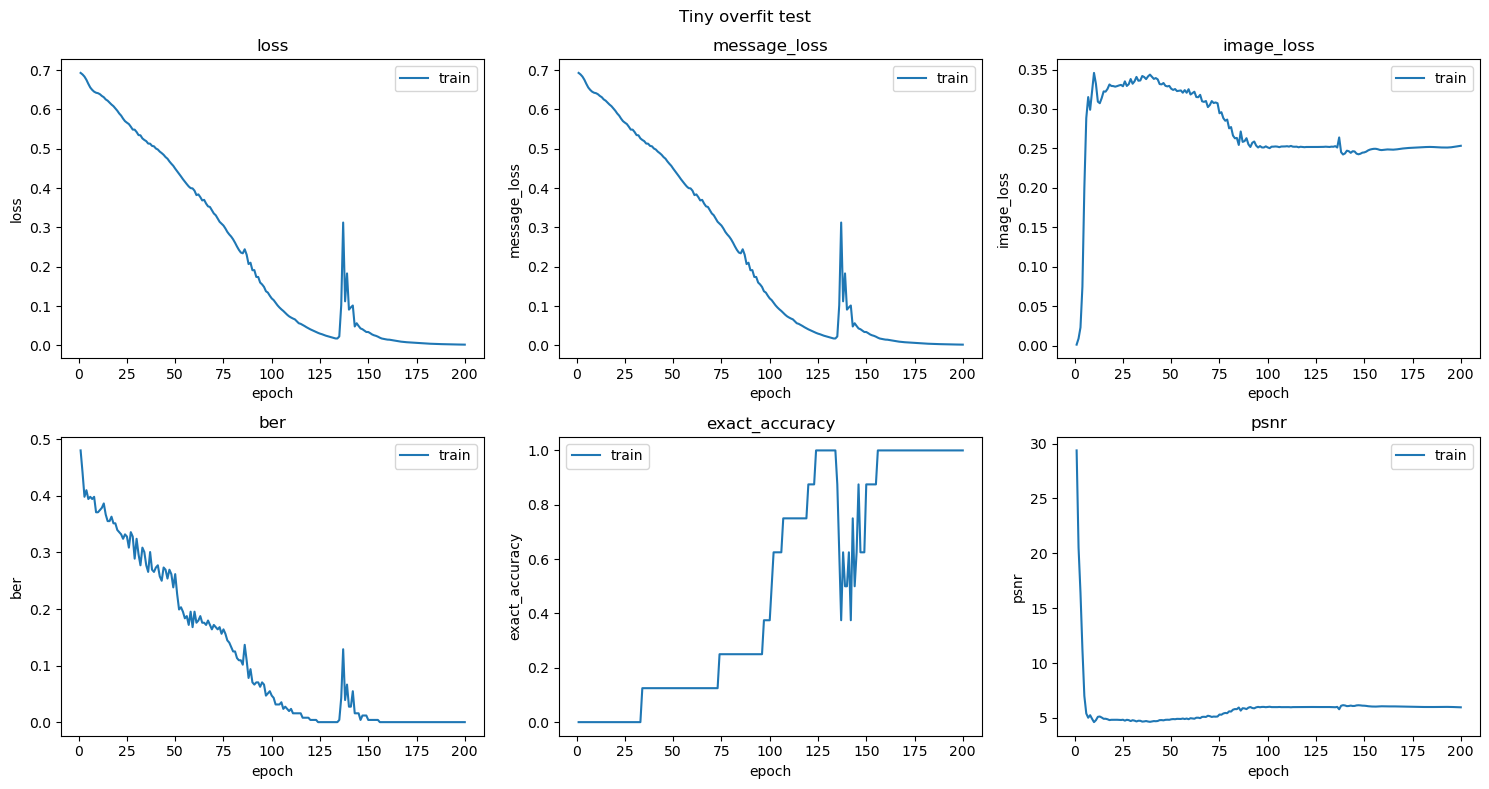

In [ ]:
small_config = TrainConfig(
    experiment_name="tiny-overfit",
    epochs=200,
    batch_size=8,
    message_length=32,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir="../results/small_overfit/checkpoints",
    log_path="../results/small_overfit/experiments.csv",
    print_every=20,
)

clear_training_log(small_config.log_path)

with open(SMALL_SPLIT_FILE, "r") as f:
    n_train_images = len(json.load(f)["train"])

fixed_train_messages = torch.randint(0, 2, (n_train_images, small_config.message_length), generator=torch.Generator().manual_seed(SEED), dtype=torch.float32)

small_train_loader, _, _ = get_dataloaders(DATA_DIR, SMALL_SPLIT_FILE, batch_size=small_config.batch_size, num_workers=0, shuffle_train=False)

small_encoder, small_decoder, small_history = fit(
    train_loader=small_train_loader,
    val_loader=small_train_loader,
    config=small_config,
    fixed_train_messages=fixed_train_messages,
    fixed_val_messages=fixed_train_messages,
)

small_df = analyze_run(small_config.log_path, name="Small overfit test", show_validation=False)

The model fully memorized all eight fixed 32-bit messages after 200 epochs. The final training BER is 0, exact message accuracy is 1 and message loss is approximately 0.002. PSNR is intentionally poor because `image_loss_weight` is set to zero in this experiment. Image quality will be optimized during baseline training.

## Full-Dataset Message-Only Diagnostic

Before balancing message recovery and image quality, we will train the model on the full dataset without an image-quality penalty. This checks whether the current architecture can learn to embed and recover new random messages across unseen validation images.

Epoch 1/20 | train_loss=0.6764 | train_BER=0.4358 | train_exact=0.0000 | val_loss=0.6672 | val_BER=0.4137 | val_exact=0.0000 | val_PSNR=10.09 | 44.0s
Epoch 2/20 | train_loss=0.6642 | train_BER=0.4202 | train_exact=0.0000 | val_loss=0.6629 | val_BER=0.4319 | val_exact=0.0000 | val_PSNR=9.27 | 43.1s
Epoch 3/20 | train_loss=0.6568 | train_BER=0.4389 | train_exact=0.0000 | val_loss=0.6531 | val_BER=0.4487 | val_exact=0.0000 | val_PSNR=9.10 | 43.1s
Epoch 4/20 | train_loss=0.6472 | train_BER=0.4412 | train_exact=0.0000 | val_loss=0.6428 | val_BER=0.4272 | val_exact=0.0000 | val_PSNR=8.75 | 43.9s
Epoch 5/20 | train_loss=0.6390 | train_BER=0.4292 | train_exact=0.0000 | val_loss=0.6344 | val_BER=0.4208 | val_exact=0.0000 | val_PSNR=8.43 | 44.0s
Epoch 6/20 | train_loss=0.6301 | train_BER=0.4227 | train_exact=0.0000 | val_loss=0.6258 | val_BER=0.4211 | val_exact=0.0000 | val_PSNR=7.47 | 43.7s
Epoch 7/20 | train_loss=0.6245 | train_BER=0.4173 | train_exact=0.0000 | val_loss=0.6217 | val_BER=0.4109

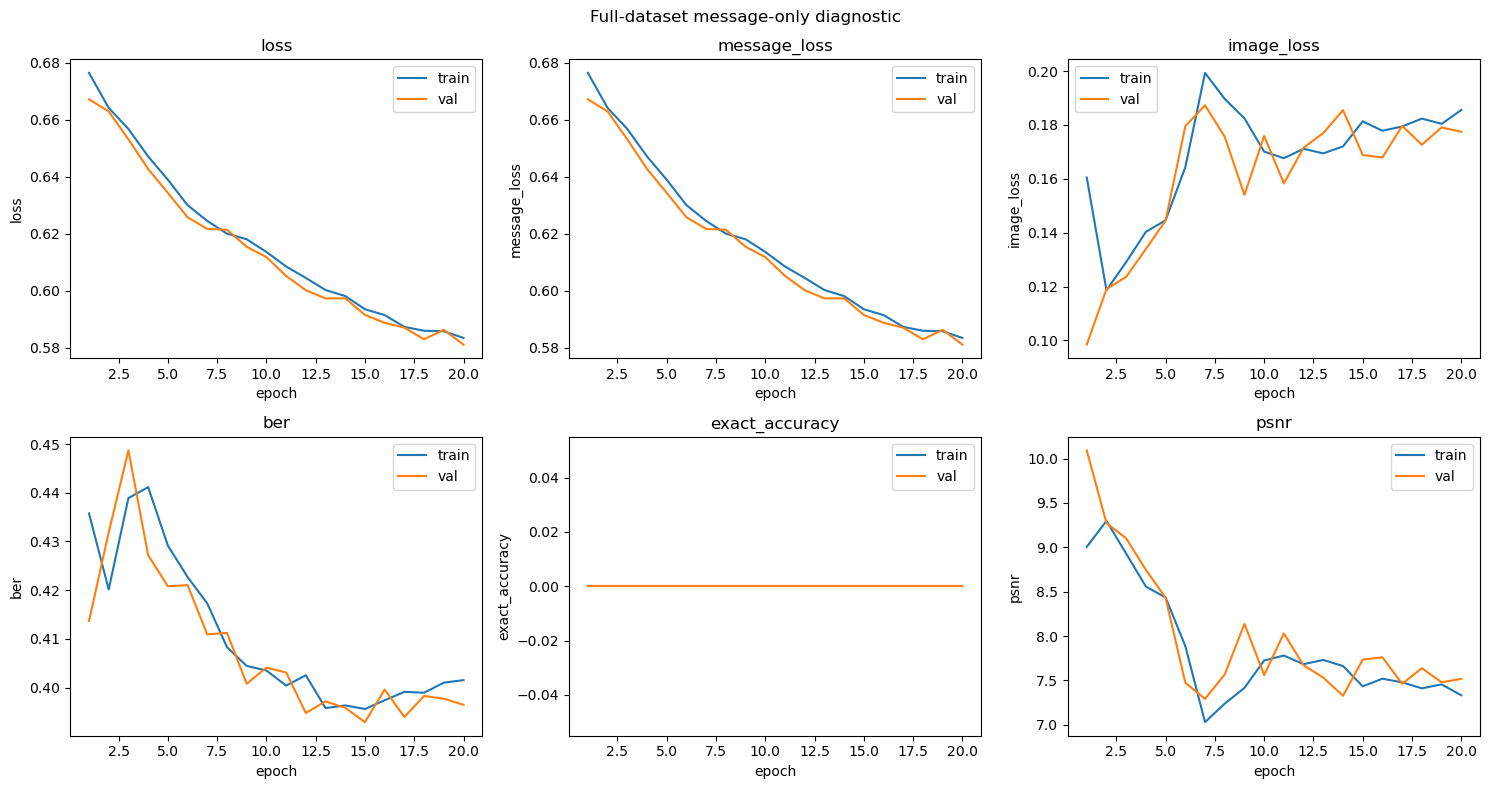

In [ ]:
full_config = TrainConfig(
    experiment_name="full-message-only",
    epochs=20,
    batch_size=32,
    message_length=32,
    encoder_channels=(64, 64, 32),
    decoder_channels=(32, 64, 128),
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir="../results/checkpoints",
    log_path="../results/logs/full-message-only.csv",
    attack_configs=None,
    print_every=1,
)

clear_training_log(full_config.log_path)

full_encoder, full_decoder, full_history = run_training(data_dir=DATA_DIR, splits_file=SPLITS_FILE, config=full_config, num_workers=4)

full_df = analyze_run(full_config.log_path, name="Full-dataset message-only diagnostic")

The train and validation losses are still decreasing at epoch 20, so we will continue the same experiment to epoch 40 from `last.pt`. The CSV log is preserved and the optimizer state is restored.

Summary for Full-dataset message-only diagnostic (40 epochs)
------------------------------------------------------------
Epochs run: 40
Training time: 30.8 minutes
Best result by val_loss: epoch 38
  train: loss=0.5541, BER=0.3772, exact_accuracy=0.0000, PSNR=7.21
  val: loss=0.5489, BER=0.3709, exact_accuracy=0.0000, PSNR=7.44
Last epoch:
  train: loss=0.5504, BER=0.3721, exact_accuracy=0.0000, PSNR=7.43
  val: loss=0.5499, BER=0.3657, exact_accuracy=0.0000, PSNR=7.55


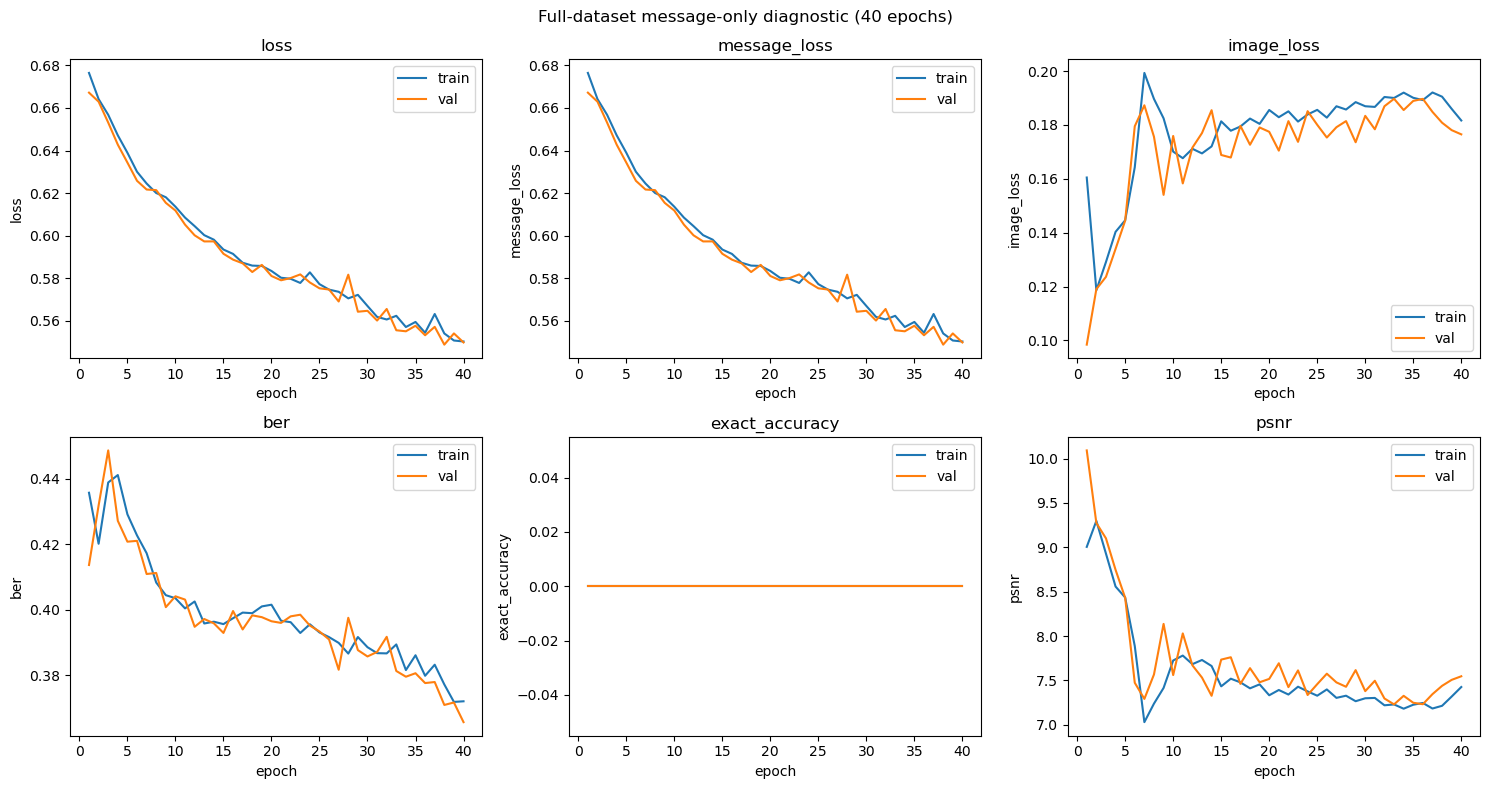

In [ ]:
full_config.epochs = 40
full_checkpoint = (
    Path(full_config.checkpoint_dir)
    / full_config.experiment_name
    / "last.pt"
)

full_encoder, full_decoder, continued_history = run_training(
    data_dir=DATA_DIR,
    splits_file=SPLITS_FILE,
    config=full_config,
    num_workers=4,
    resume_from=full_checkpoint,
)

full_history.extend(continued_history)
full_df = analyze_run(full_config.log_path, name="Full-dataset message-only diagnostic (40 epochs)")

After 40 epochs, validation BER reaches 0.3657 and validation message loss falls to 0.5499. Train and validation curves remain close and continue to improve, confirming that the model learns a signal that transfers to unseen images.

Exact message accuracy remains 0, and PSNR is only 7.55 dB because image quality is not part of this diagnostic objective. This run is useful as a learning check, but it is not a baseline candidate.

## Preliminary loss and learning-rate checks

Before the systematic baseline sweep, three preliminary 32-bit configurations were trained: a balanced loss, the same loss with a lower learning rate and a message-focused loss.

Summary for full_balanced
-------------------------
Epochs run: 20
Best epoch: 20 (val_loss=0.6276)
  val_ber=0.4243, val_exact_accuracy=0.0000, val_psnr=14.02
Last epoch stats:
  train_loss=0.6304, val_loss=0.6276
  val_ber=0.4243, val_exact_accuracy=0.0000, val_psnr=14.02


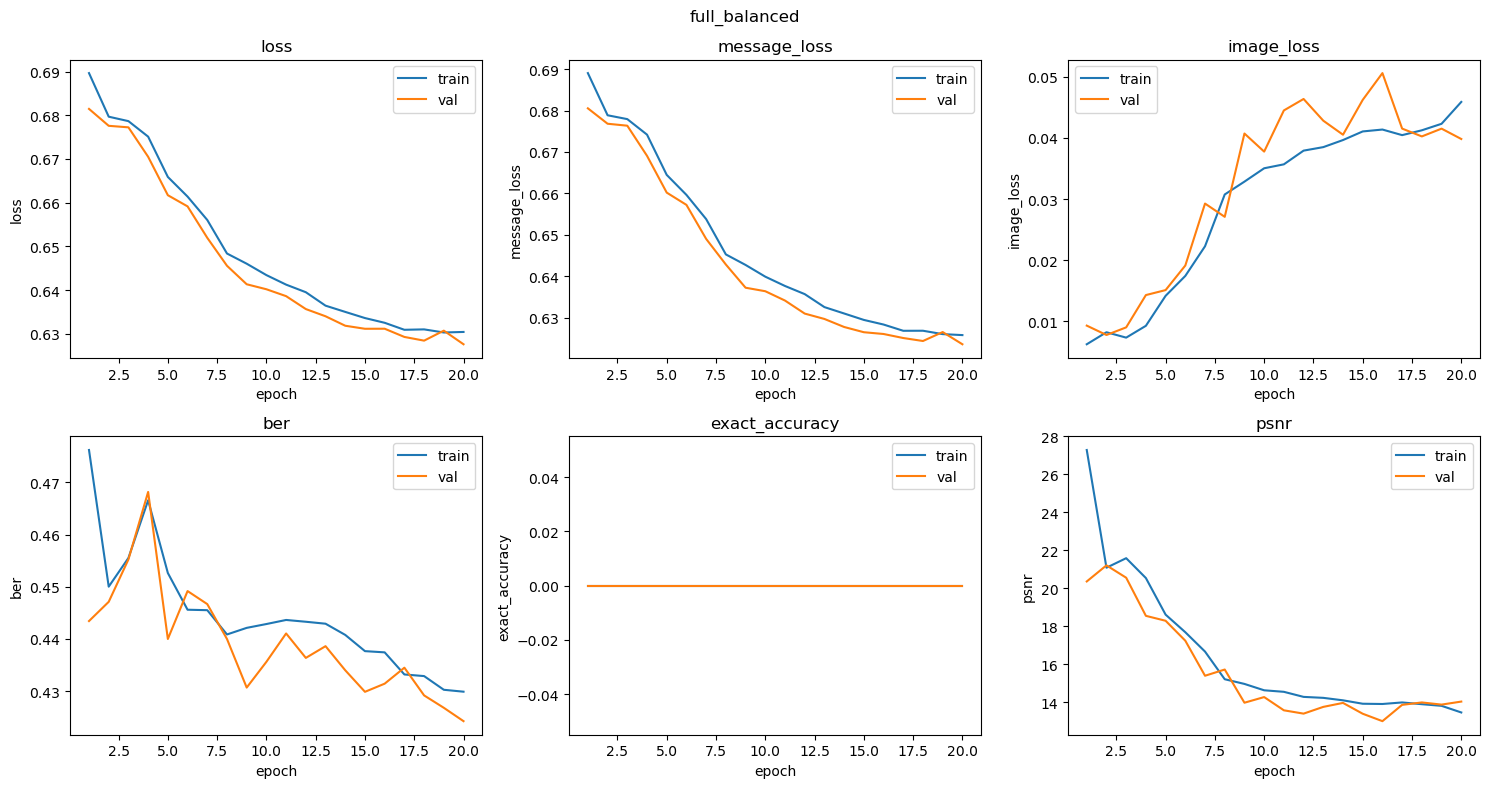

Summary for full_balanced_low_lr
--------------------------------
Epochs run: 20
Best epoch: 20 (val_loss=0.6084)
  val_ber=0.3970, val_exact_accuracy=0.0000, val_psnr=13.28
Last epoch stats:
  train_loss=0.6107, val_loss=0.6084
  val_ber=0.3970, val_exact_accuracy=0.0000, val_psnr=13.28


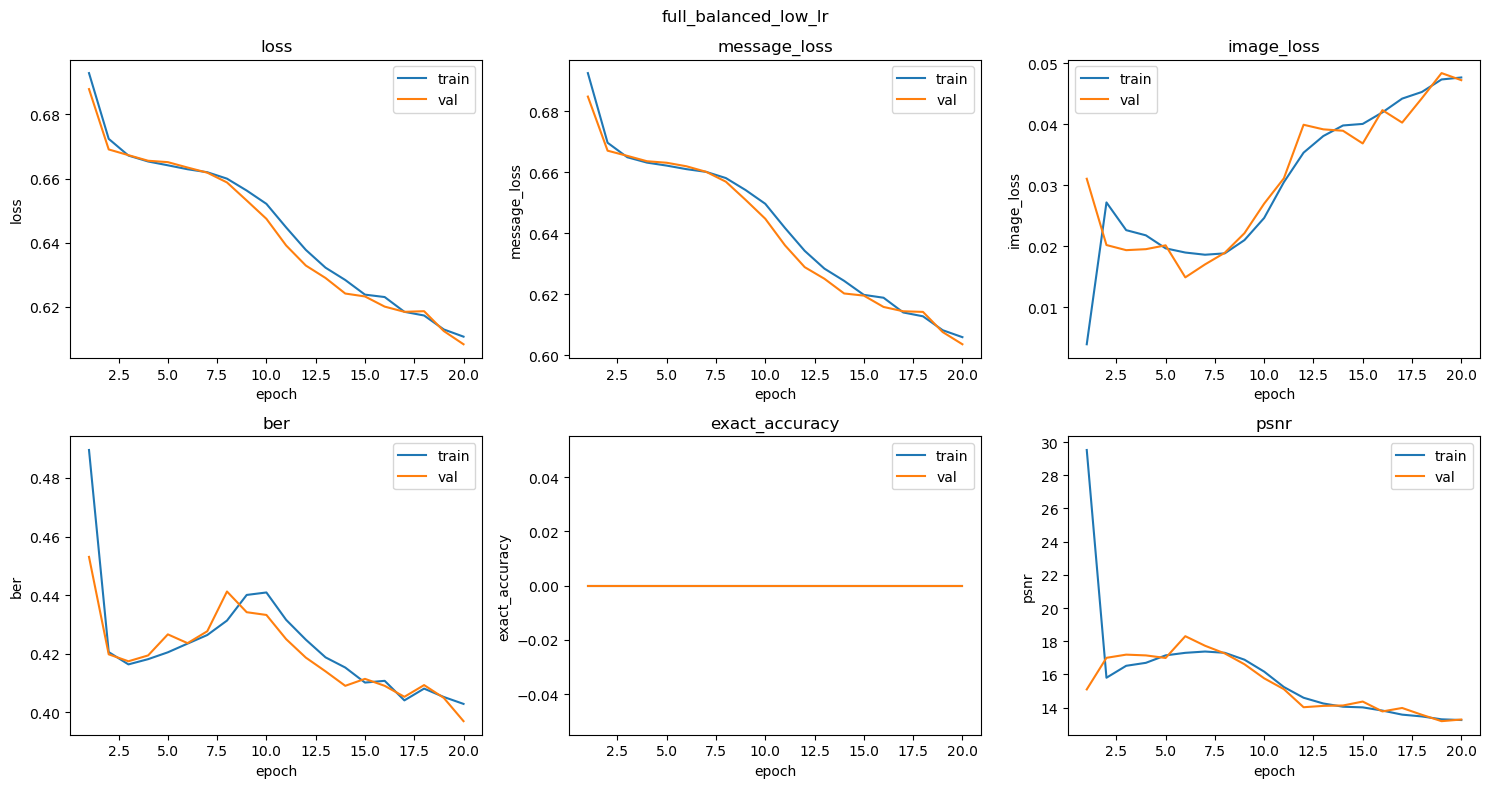

Summary for full_message_focused
--------------------------------
Epochs run: 20
Best epoch: 20 (val_loss=0.5787)
  val_ber=0.3738, val_exact_accuracy=0.0000, val_psnr=9.19
Last epoch stats:
  train_loss=0.5856, val_loss=0.5787
  val_ber=0.3738, val_exact_accuracy=0.0000, val_psnr=9.19


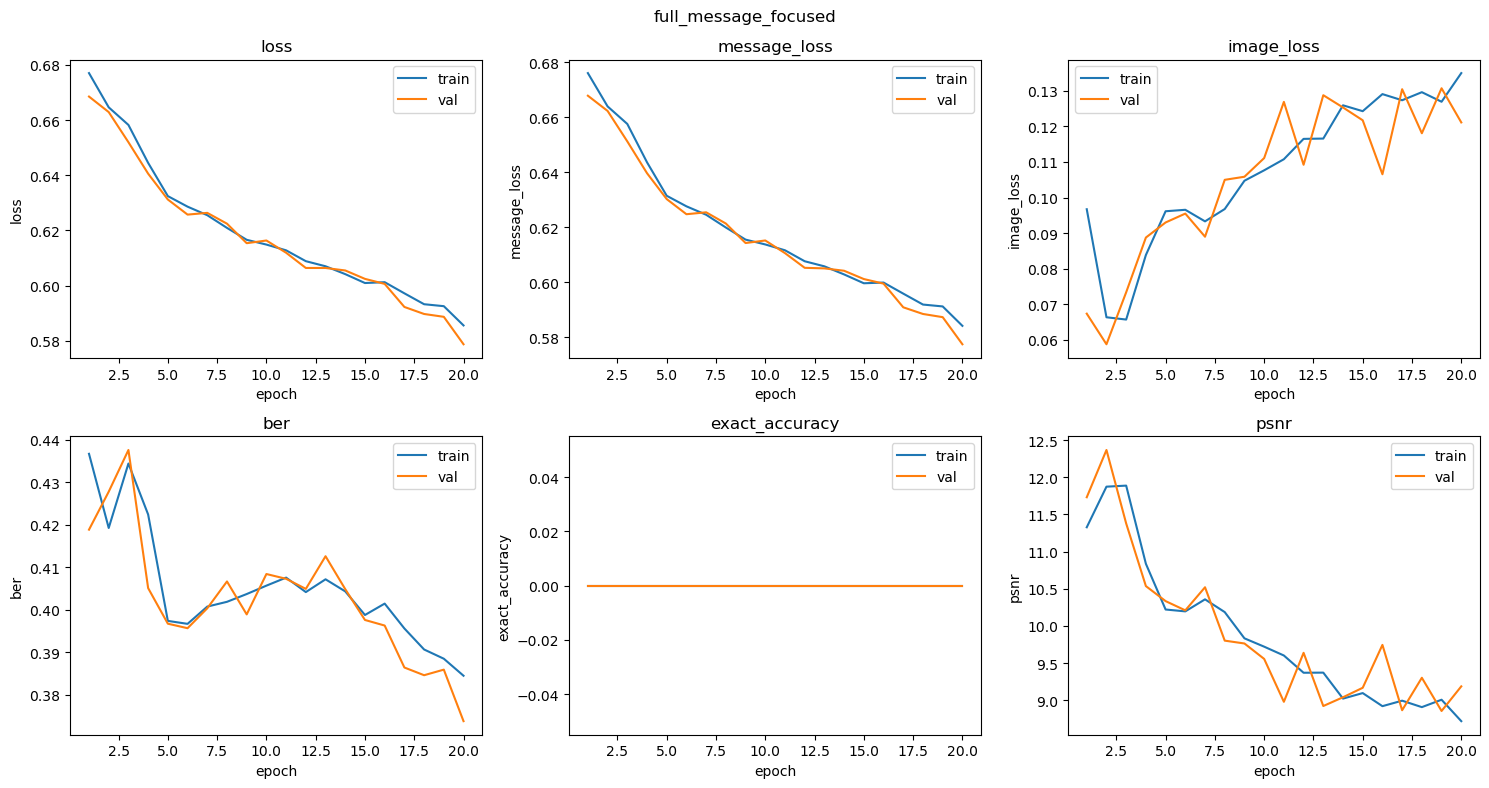

In [31]:
full_experiment_configs = [
    {
        "name": "full_balanced",
        "learning_rate": 1e-3,
        "image_loss_weight": 0.1,
    },
    {
        "name": "full_balanced_low_lr",
        "learning_rate": 3e-4,
        "image_loss_weight": 0.1,
    },
    {
        "name": "full_message_focused",
        "learning_rate": 1e-3,
        "image_loss_weight": 0.01,
    },
]

full_experiment_results = {}

for experiment in full_experiment_configs:
    experiment_name = experiment["name"]
    config = TrainConfig(
        experiment_name=experiment_name,
        epochs=20,
        batch_size=32,
        message_length=32,
        learning_rate=experiment["learning_rate"],
        image_loss_weight=experiment["image_loss_weight"],
        device="cuda",
        checkpoint_dir=f"../results/{experiment_name}/checkpoints",
        log_path=f"../results/{experiment_name}/experiments.csv",
    )

    clear_training_log(config.log_path)

    encoder, decoder, history = run_training(data_dir=DATA_DIR, splits_file=SPLITS_FILE, config=config, num_workers=4)

    full_experiment_results[experiment_name] = analyze_run(config.log_path, name=experiment_name)

## Clean baseline candidates

We will now keep the learning rate and vary only `image_loss_weight`. This isolates the trade-off between message recovery and image quality. After selecting a useful weight range, model channel sizes can be compared separately.

Epoch 1/20 | train_loss=0.6849 | train_BER=0.4596 | train_exact=0.0000 | val_loss=0.6799 | val_BER=0.4437 | val_exact=0.0000 | val_PSNR=14.41 | 44.3s
Epoch 2/20 | train_loss=0.6798 | train_BER=0.4473 | train_exact=0.0000 | val_loss=0.6784 | val_BER=0.4446 | val_exact=0.0000 | val_PSNR=15.82 | 45.9s
Epoch 3/20 | train_loss=0.6788 | train_BER=0.4499 | train_exact=0.0000 | val_loss=0.6752 | val_BER=0.4456 | val_exact=0.0000 | val_PSNR=16.48 | 45.2s
Epoch 4/20 | train_loss=0.6703 | train_BER=0.4402 | train_exact=0.0000 | val_loss=0.6584 | val_BER=0.4261 | val_exact=0.0000 | val_PSNR=11.93 | 45.8s
Epoch 5/20 | train_loss=0.6540 | train_BER=0.4154 | train_exact=0.0000 | val_loss=0.6488 | val_BER=0.4077 | val_exact=0.0000 | val_PSNR=11.65 | 47.3s
Epoch 6/20 | train_loss=0.6461 | train_BER=0.4086 | train_exact=0.0000 | val_loss=0.6446 | val_BER=0.4092 | val_exact=0.0000 | val_PSNR=12.33 | 45.5s
Epoch 7/20 | train_loss=0.6440 | train_BER=0.4171 | train_exact=0.0000 | val_loss=0.6420 | val_BER=0

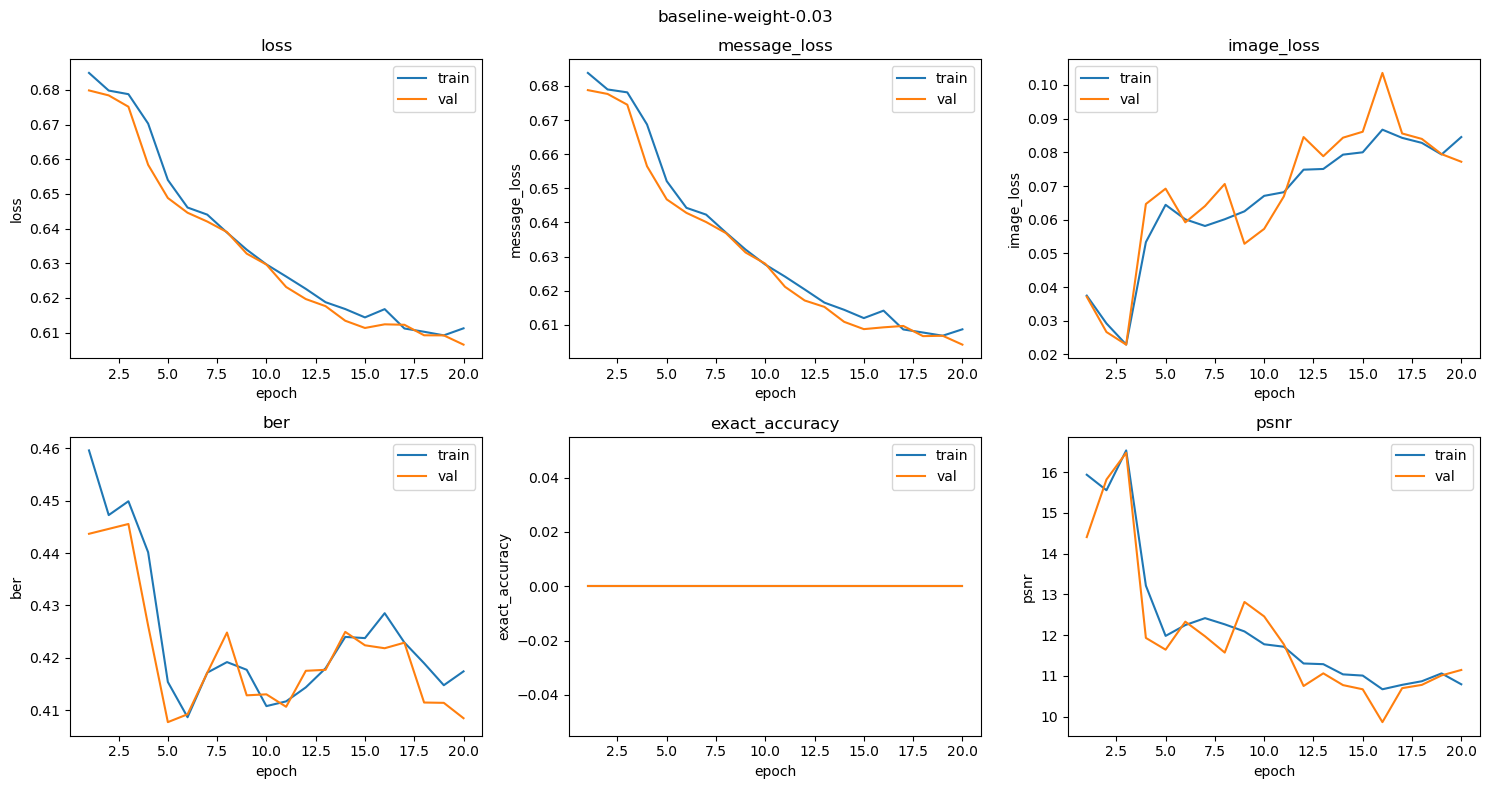

Epoch 1/20 | train_loss=0.6897 | train_BER=0.4757 | train_exact=0.0000 | val_loss=0.6814 | val_BER=0.4440 | val_exact=0.0000 | val_PSNR=20.54 | 56.2s
Epoch 2/20 | train_loss=0.6799 | train_BER=0.4505 | train_exact=0.0000 | val_loss=0.6779 | val_BER=0.4466 | val_exact=0.0000 | val_PSNR=21.16 | 54.8s
Epoch 3/20 | train_loss=0.6788 | train_BER=0.4540 | train_exact=0.0000 | val_loss=0.6771 | val_BER=0.4516 | val_exact=0.0000 | val_PSNR=20.85 | 47.2s
Epoch 4/20 | train_loss=0.6766 | train_BER=0.4616 | train_exact=0.0000 | val_loss=0.6738 | val_BER=0.4655 | val_exact=0.0000 | val_PSNR=19.64 | 44.9s
Epoch 5/20 | train_loss=0.6679 | train_BER=0.4612 | train_exact=0.0000 | val_loss=0.6632 | val_BER=0.4511 | val_exact=0.0000 | val_PSNR=18.45 | 44.3s
Epoch 6/20 | train_loss=0.6619 | train_BER=0.4508 | train_exact=0.0000 | val_loss=0.6582 | val_BER=0.4443 | val_exact=0.0000 | val_PSNR=17.80 | 44.4s
Epoch 7/20 | train_loss=0.6565 | train_BER=0.4462 | train_exact=0.0000 | val_loss=0.6533 | val_BER=0

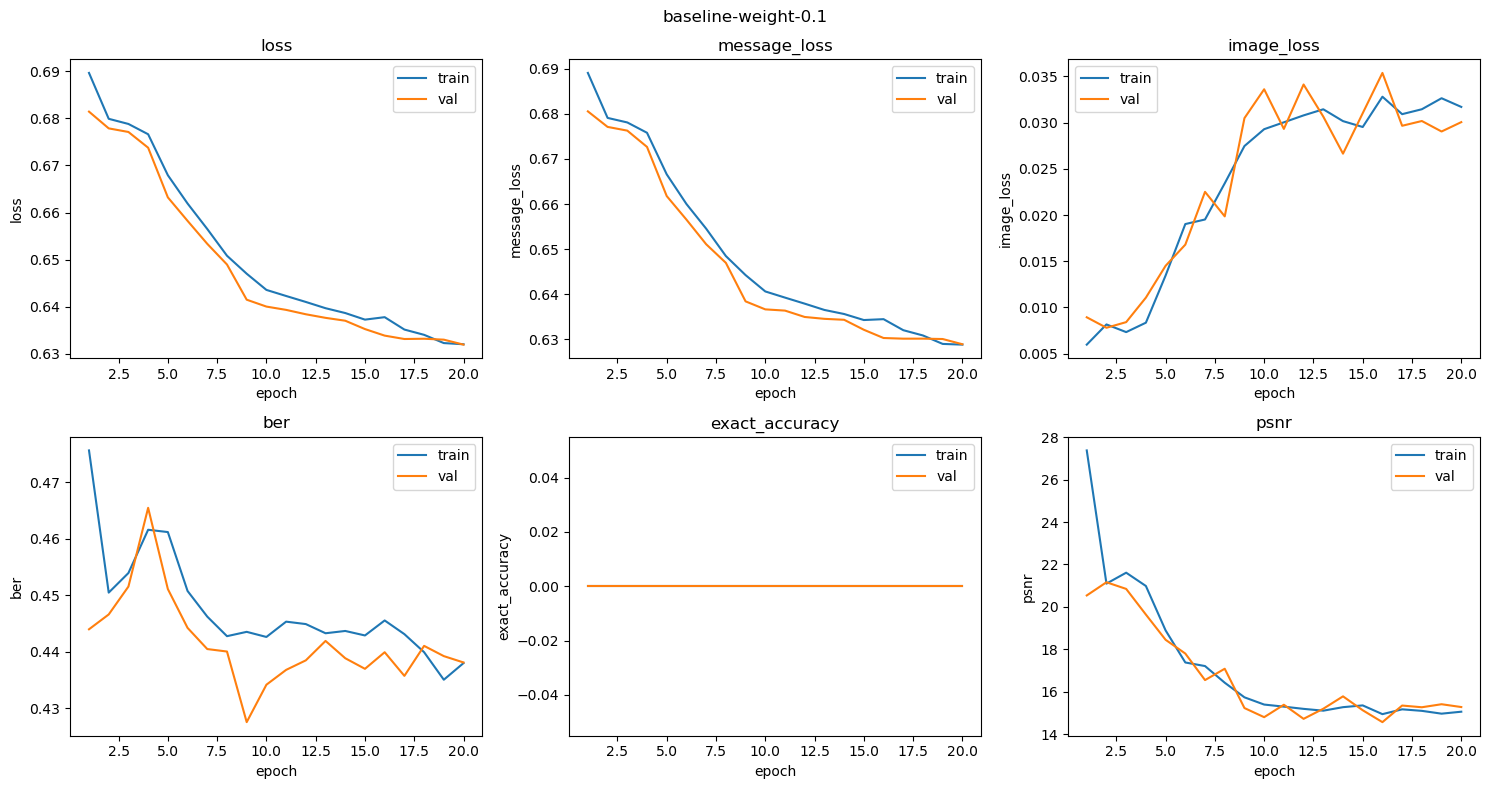

Epoch 1/20 | train_loss=0.6934 | train_BER=0.5005 | train_exact=0.0000 | val_loss=0.6933 | val_BER=0.4949 | val_exact=0.0000 | val_PSNR=50.62 | 43.7s
Epoch 2/20 | train_loss=0.6932 | train_BER=0.4999 | train_exact=0.0000 | val_loss=0.6932 | val_BER=0.5010 | val_exact=0.0000 | val_PSNR=61.67 | 44.3s
Epoch 3/20 | train_loss=0.6919 | train_BER=0.4919 | train_exact=0.0000 | val_loss=0.6869 | val_BER=0.4559 | val_exact=0.0000 | val_PSNR=25.04 | 47.4s
Epoch 4/20 | train_loss=0.6852 | train_BER=0.4533 | train_exact=0.0000 | val_loss=0.6813 | val_BER=0.4533 | val_exact=0.0000 | val_PSNR=26.54 | 43.6s
Epoch 5/20 | train_loss=0.6801 | train_BER=0.4524 | train_exact=0.0000 | val_loss=0.6787 | val_BER=0.4522 | val_exact=0.0000 | val_PSNR=23.79 | 43.6s
Epoch 6/20 | train_loss=0.6768 | train_BER=0.4616 | train_exact=0.0000 | val_loss=0.6731 | val_BER=0.4776 | val_exact=0.0000 | val_PSNR=22.52 | 43.8s
Epoch 7/20 | train_loss=0.6689 | train_BER=0.4546 | train_exact=0.0000 | val_loss=0.6646 | val_BER=0

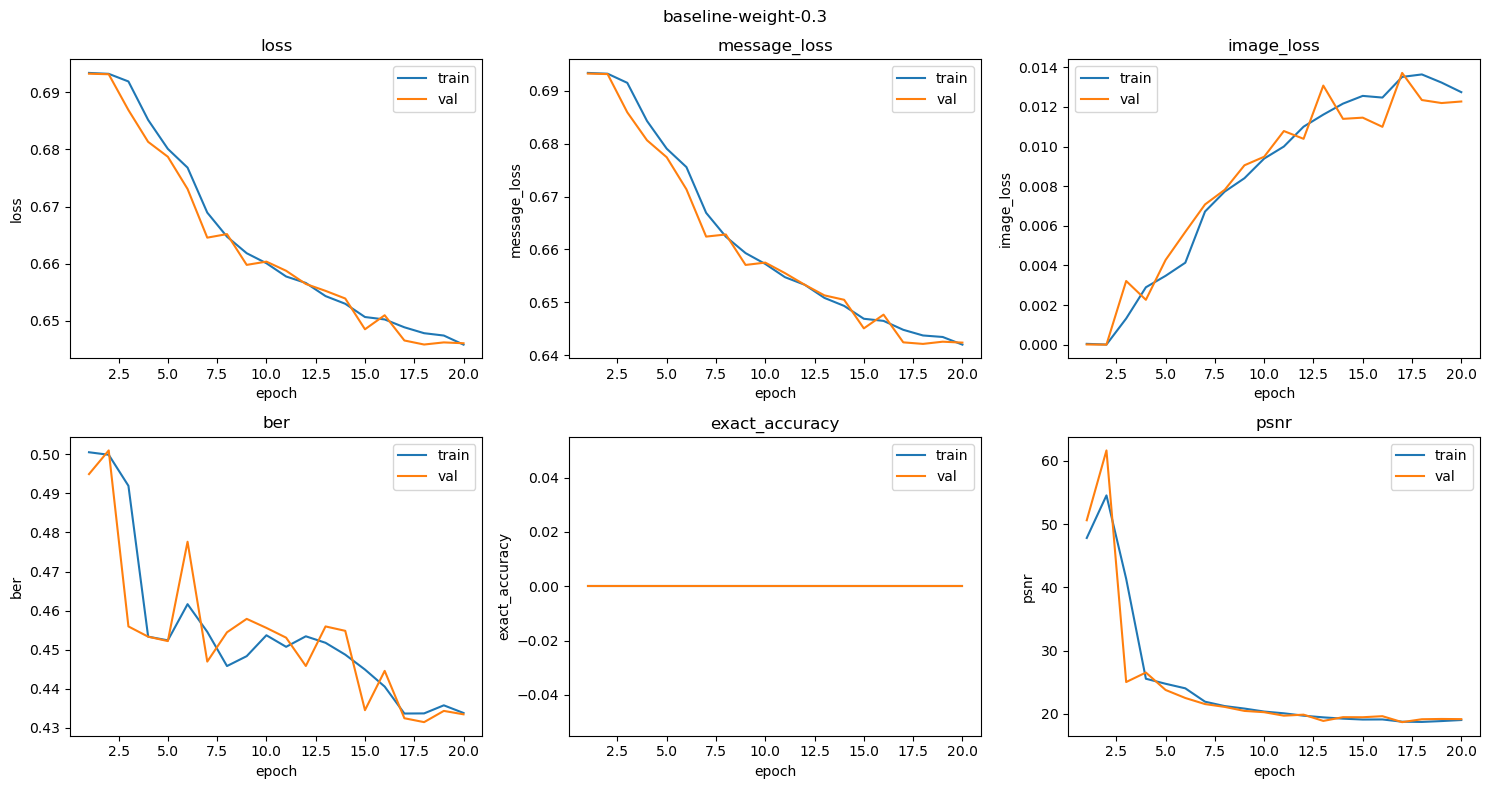

In [ ]:
baseline_experiment_configs = [
    {
        "name": "baseline-weight-0.03",
        "image_loss_weight": 0.03,
    },
    {
        "name": "baseline-weight-0.1",
        "image_loss_weight": 0.1,
    },
    {
        "name": "baseline-weight-0.3",
        "image_loss_weight": 0.3,
    },
]

baseline_results = {}

for experiment in baseline_experiment_configs:
    experiment_name = experiment["name"]
    config = TrainConfig(
        experiment_name=experiment_name,
        epochs=20,
        batch_size=32,
        message_length=32,
        encoder_channels=(64, 64, 32),
        decoder_channels=(32, 64, 128),
        learning_rate=1e-3,
        image_loss_weight=experiment["image_loss_weight"],
        device="cuda",
        checkpoint_dir="../results/checkpoints",
        log_path=f"../results/logs/{experiment_name}.csv",
        attack_configs=None,
        print_every=1,
    )

    clear_training_log(config.log_path)

    encoder, decoder, history = run_training(data_dir=DATA_DIR, splits_file=SPLITS_FILE, config=config, num_workers=4)

    baseline_results[experiment_name] = analyze_run(config.log_path, name=experiment_name)

In [40]:
baseline_summary = pd.DataFrame(
    [
        {
            "experiment": name,
            "image_loss_weight": df.iloc[0]["image_loss_weight"],
            "val_ber": df.loc[df["val_loss"].idxmin(), "val_ber"],
            "val_exact_accuracy": df.loc[
                df["val_loss"].idxmin(),
                "val_exact_accuracy",
            ],
            "val_psnr": df.loc[df["val_loss"].idxmin(), "val_psnr"],
            "training_minutes": df["epoch_seconds"].sum() / 60,
        }
        for name, df in baseline_results.items()
    ]
)

baseline_summary

,experiment,image_loss_weight,val_ber,val_exact_accuracy,val_psnr,training_minutes
0,baseline-weight-0.03,0.03,0.408437,0.0,11.146822,16.807485
1,baseline-weight-0.1,0.10,0.438125,0.0,15.272470,15.106450
2,baseline-weight-0.3,0.30,0.431437,0.0,19.157127,14.581562


We can see that increasing `image_loss_weight` improves PSNR, but none of the three 20-epoch runs recovers complete validation messages. Weight `0.3` gives the best image quality while keeping BER in the same range as weight `0.1`, so it is used for the next controlled comparison of model capacity.

## Model capacity comparison

We will keep `image_loss_weight=0.3` and all training settings fixed. The existing default model is compared with a smaller model and a moderately wider model. This tests whether channel capacity changes message recovery without mixing that effect with a different loss balance.

Epoch 1/20 | train_loss=0.6935 | train_BER=0.4982 | train_exact=0.0000 | val_loss=0.6933 | val_BER=0.5005 | val_exact=0.0000 | val_PSNR=52.32 | 36.6s
Epoch 2/20 | train_loss=0.6933 | train_BER=0.5020 | train_exact=0.0000 | val_loss=0.6931 | val_BER=0.4964 | val_exact=0.0000 | val_PSNR=37.98 | 37.4s
Epoch 3/20 | train_loss=0.6876 | train_BER=0.4596 | train_exact=0.0000 | val_loss=0.6810 | val_BER=0.4385 | val_exact=0.0000 | val_PSNR=24.41 | 37.0s
Epoch 4/20 | train_loss=0.6807 | train_BER=0.4396 | train_exact=0.0000 | val_loss=0.6804 | val_BER=0.4385 | val_exact=0.0000 | val_PSNR=24.76 | 37.8s
Epoch 5/20 | train_loss=0.6805 | train_BER=0.4402 | train_exact=0.0000 | val_loss=0.6805 | val_BER=0.4429 | val_exact=0.0000 | val_PSNR=24.84 | 37.6s
Epoch 6/20 | train_loss=0.6802 | train_BER=0.4423 | train_exact=0.0000 | val_loss=0.6800 | val_BER=0.4445 | val_exact=0.0000 | val_PSNR=25.15 | 37.9s
Epoch 7/20 | train_loss=0.6790 | train_BER=0.4437 | train_exact=0.0000 | val_loss=0.6799 | val_BER=0

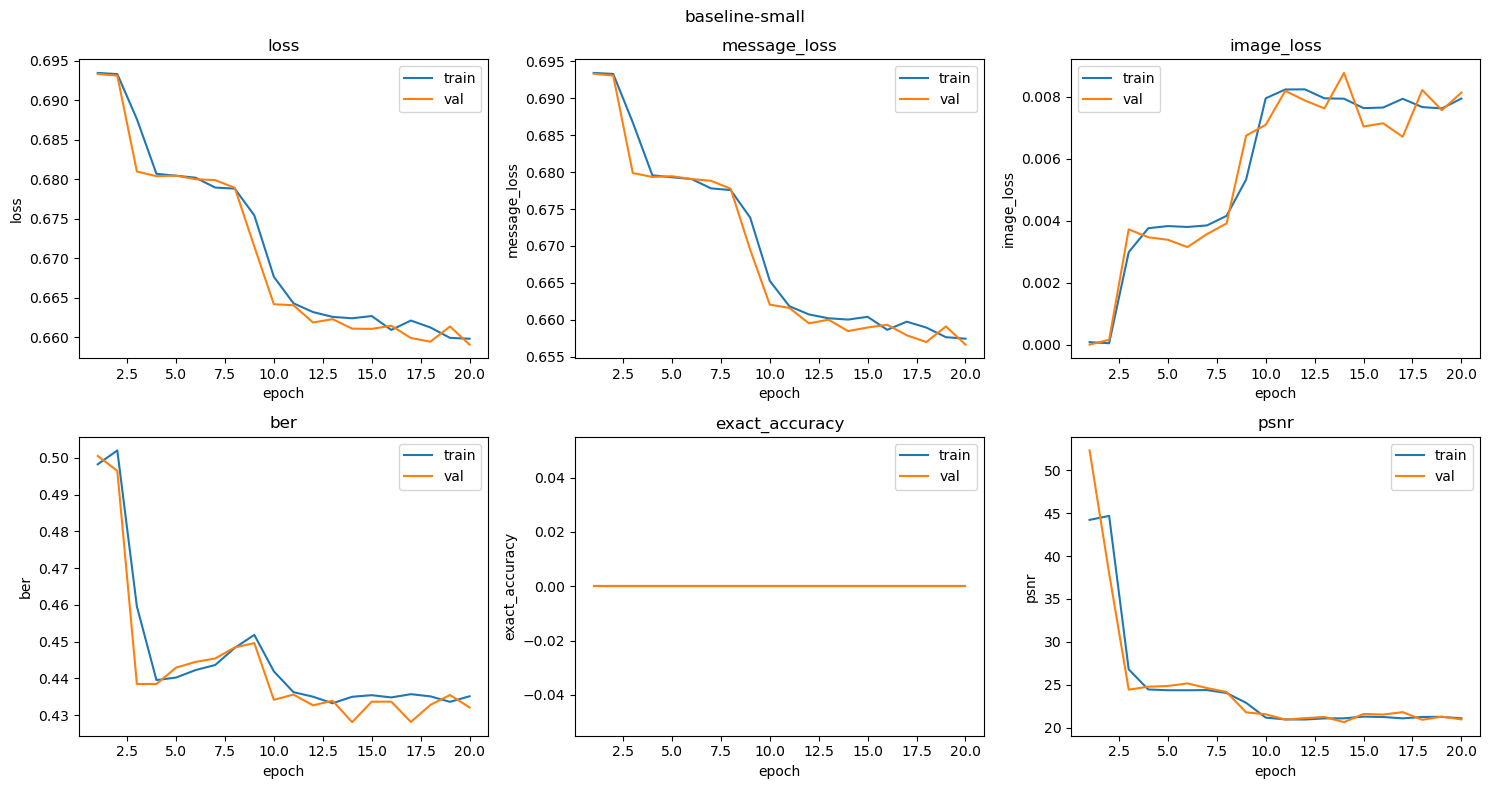

Epoch 1/20 | train_loss=0.6933 | train_BER=0.4983 | train_exact=0.0000 | val_loss=0.6932 | val_BER=0.4987 | val_exact=0.0000 | val_PSNR=54.61 | 62.4s
Epoch 2/20 | train_loss=0.6933 | train_BER=0.5009 | train_exact=0.0000 | val_loss=0.6932 | val_BER=0.5038 | val_exact=0.0000 | val_PSNR=60.20 | 63.6s
Epoch 3/20 | train_loss=0.6932 | train_BER=0.5025 | train_exact=0.0000 | val_loss=0.6931 | val_BER=0.4946 | val_exact=0.0000 | val_PSNR=64.11 | 58.7s
Epoch 4/20 | train_loss=0.6932 | train_BER=0.4990 | train_exact=0.0000 | val_loss=0.6930 | val_BER=0.4914 | val_exact=0.0000 | val_PSNR=66.48 | 58.3s
Epoch 5/20 | train_loss=0.6932 | train_BER=0.5004 | train_exact=0.0000 | val_loss=0.6931 | val_BER=0.4947 | val_exact=0.0000 | val_PSNR=67.88 | 57.9s
Epoch 6/20 | train_loss=0.6932 | train_BER=0.4984 | train_exact=0.0000 | val_loss=0.6932 | val_BER=0.4994 | val_exact=0.0000 | val_PSNR=70.03 | 57.8s
Epoch 7/20 | train_loss=0.6932 | train_BER=0.5020 | train_exact=0.0000 | val_loss=0.6931 | val_BER=0

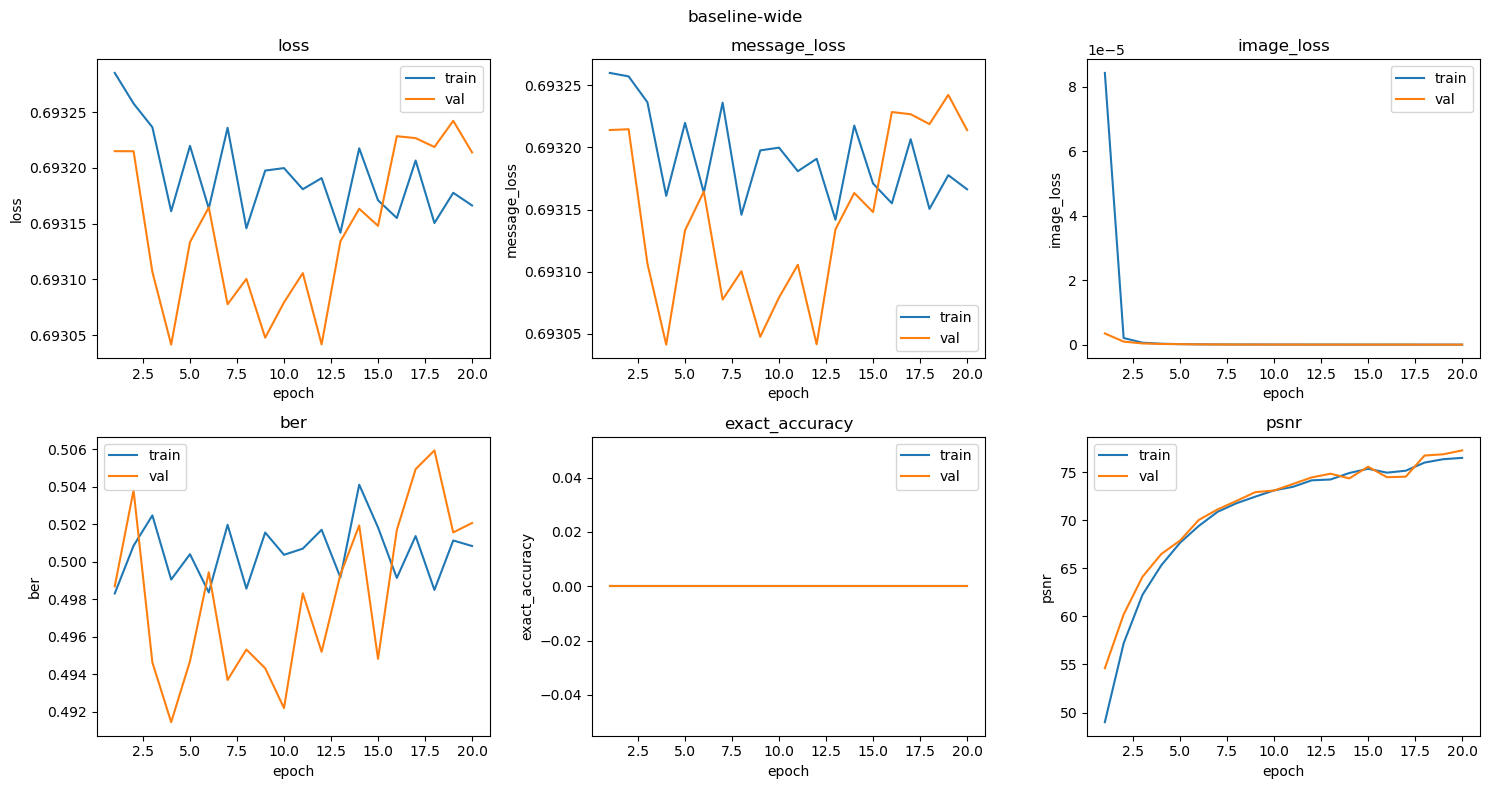

In [ ]:
capacity_experiment_configs = [
    {
        "name": "baseline-small",
        "encoder_channels": (32, 32, 16),
        "decoder_channels": (16, 32, 64),
    },
    {
        "name": "baseline-wide",
        "encoder_channels": (96, 96, 48),
        "decoder_channels": (48, 96, 192),
    },
]

capacity_results = { "baseline-default": baseline_results["baseline-weight-0.3"] }

for experiment in capacity_experiment_configs:
    experiment_name = experiment["name"]
    config = TrainConfig(
        experiment_name=experiment_name,
        epochs=20,
        batch_size=32,
        message_length=32,
        encoder_channels=experiment["encoder_channels"],
        decoder_channels=experiment["decoder_channels"],
        learning_rate=1e-3,
        image_loss_weight=0.3,
        device="cuda",
        checkpoint_dir="../results/checkpoints",
        log_path=f"../results/logs/{experiment_name}.csv",
        attack_configs=None,
        print_every=1,
    )

    clear_training_log(config.log_path)

    encoder, decoder, history = run_training(data_dir=DATA_DIR, splits_file=SPLITS_FILE, config=config, num_workers=4)

    capacity_results[experiment_name] = analyze_run(config.log_path, name=experiment_name)

In [42]:
capacity_summary = pd.DataFrame(
    [
        {
            "experiment": name,
            "encoder_channels": df.iloc[0]["encoder_channels"],
            "decoder_channels": df.iloc[0]["decoder_channels"],
            "val_ber": df.loc[df["val_loss"].idxmin(), "val_ber"],
            "val_exact_accuracy": df.loc[
                df["val_loss"].idxmin(),
                "val_exact_accuracy",
            ],
            "val_psnr": df.loc[df["val_loss"].idxmin(), "val_psnr"],
            "training_minutes": df["epoch_seconds"].sum() / 60,
        }
        for name, df in capacity_results.items()
    ]
)

capacity_summary

,experiment,encoder_channels,decoder_channels,val_ber,val_exact_accuracy,val_psnr,training_minutes
0,baseline-default,"[64, 64, 32]","[32, 64, 128]",0.431437,0.0,19.157127,14.581562
1,baseline-small,"[32, 32, 16]","[16, 32, 64]",0.432125,0.0,20.944580,12.885950
2,baseline-wide,"[96, 96, 48]","[48, 96, 192]",0.491438,0.0,66.478302,19.503692


The small and default models have nearly identical validation BER, but the small model has higher PSNR and trains faster. The wide model collapses to the image-preserving solution and does not learn the message signal. We will use the small model to test whether additional epochs improve message recovery.

Epoch 21/40 | train_loss=0.6593 | train_BER=0.4365 | train_exact=0.0000 | val_loss=0.6581 | val_BER=0.4328 | val_exact=0.0000 | val_PSNR=21.05 | 36.7s
Epoch 22/40 | train_loss=0.6587 | train_BER=0.4398 | train_exact=0.0000 | val_loss=0.6565 | val_BER=0.4349 | val_exact=0.0000 | val_PSNR=20.80 | 38.4s
Epoch 23/40 | train_loss=0.6563 | train_BER=0.4389 | train_exact=0.0000 | val_loss=0.6548 | val_BER=0.4374 | val_exact=0.0000 | val_PSNR=20.84 | 40.6s
Epoch 24/40 | train_loss=0.6546 | train_BER=0.4374 | train_exact=0.0000 | val_loss=0.6540 | val_BER=0.4401 | val_exact=0.0000 | val_PSNR=20.91 | 38.5s
Epoch 25/40 | train_loss=0.6531 | train_BER=0.4406 | train_exact=0.0000 | val_loss=0.6528 | val_BER=0.4417 | val_exact=0.0000 | val_PSNR=20.31 | 38.5s
Epoch 26/40 | train_loss=0.6515 | train_BER=0.4424 | train_exact=0.0000 | val_loss=0.6502 | val_BER=0.4423 | val_exact=0.0000 | val_PSNR=20.86 | 33.5s
Epoch 27/40 | train_loss=0.6502 | train_BER=0.4442 | train_exact=0.0000 | val_loss=0.6491 | va

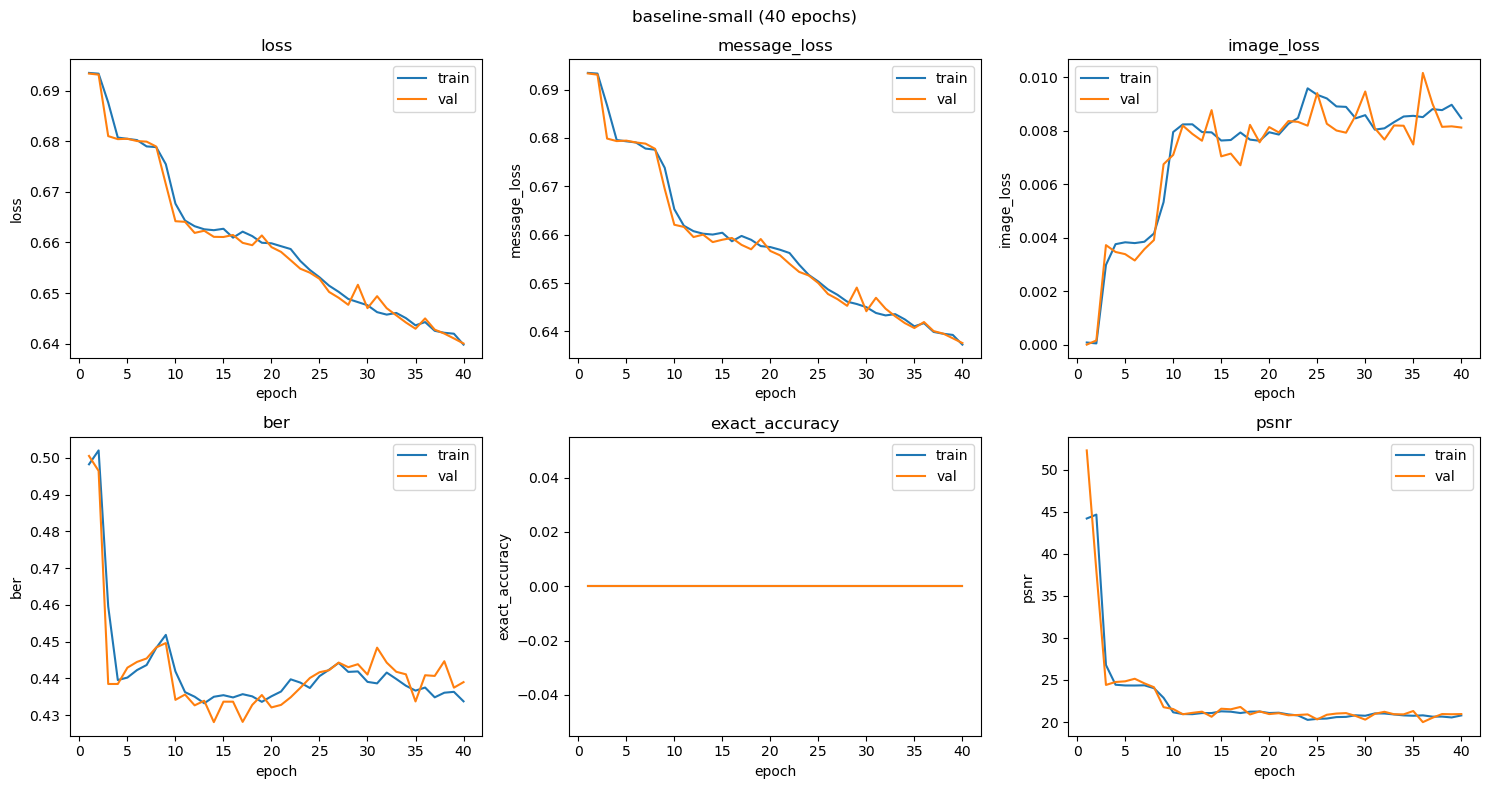

In [ ]:
small_baseline_config = TrainConfig(
    experiment_name="baseline-small",
    epochs=40,
    batch_size=32,
    message_length=32,
    encoder_channels=(32, 32, 16),
    decoder_channels=(16, 32, 64),
    learning_rate=1e-3,
    image_loss_weight=0.3,
    device="cuda",
    checkpoint_dir="../results/checkpoints",
    log_path="../results/logs/baseline-small.csv",
    attack_configs=None,
    print_every=1,
)
small_baseline_checkpoint = (
    Path(small_baseline_config.checkpoint_dir)
    / small_baseline_config.experiment_name
    / "last.pt"
)

small_baseline_encoder, small_baseline_decoder, continued_history = run_training(
    data_dir=DATA_DIR,
    splits_file=SPLITS_FILE,
    config=small_baseline_config,
    num_workers=4,
    resume_from=small_baseline_checkpoint,
)

capacity_results["baseline-small"] = analyze_run(small_baseline_config.log_path, name="baseline-small (40 epochs)")

Continuing the small model to 40 epochs reduces validation loss, but validation BER remains around 0.44 and exact message accuracy remains 0. Additional epochs alone do not solve message recovery for this objective.

None of the current runs is a usable final baseline. The next experiment should start from the full-dataset message-only checkpoint and gradually introduce the image-quality loss. This separates learning the message channel from compressing the watermark signal.

## 16-Bit constrained model

We will now reduce the message length to 16 bits and limit each encoder pixel change to `0.03`. The hard residual limit guarantees that the model cannot obtain good message recovery by heavily distorting the image. Noise attacks remain disabled.

Epoch 1/200 | train_loss=0.6891 | train_BER=0.4609 | train_exact=0.0000 | 0.2s
Epoch 20/200 | train_loss=0.5976 | train_BER=0.3281 | train_exact=0.0000 | 0.2s
Epoch 40/200 | train_loss=0.4143 | train_BER=0.2188 | train_exact=0.1250 | 0.2s
Epoch 60/200 | train_loss=0.3561 | train_BER=0.2031 | train_exact=0.1250 | 0.2s
Epoch 80/200 | train_loss=0.2719 | train_BER=0.1250 | train_exact=0.1250 | 0.2s
Epoch 100/200 | train_loss=0.1694 | train_BER=0.0312 | train_exact=0.7500 | 0.2s
Epoch 120/200 | train_loss=0.0942 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Epoch 140/200 | train_loss=0.0497 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Epoch 160/200 | train_loss=0.0261 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Epoch 180/200 | train_loss=0.0144 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Epoch 200/200 | train_loss=0.0086 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Training time: 0.7 minutes
Summary for 16-bit constrained tiny overfit
-------------------------------------------


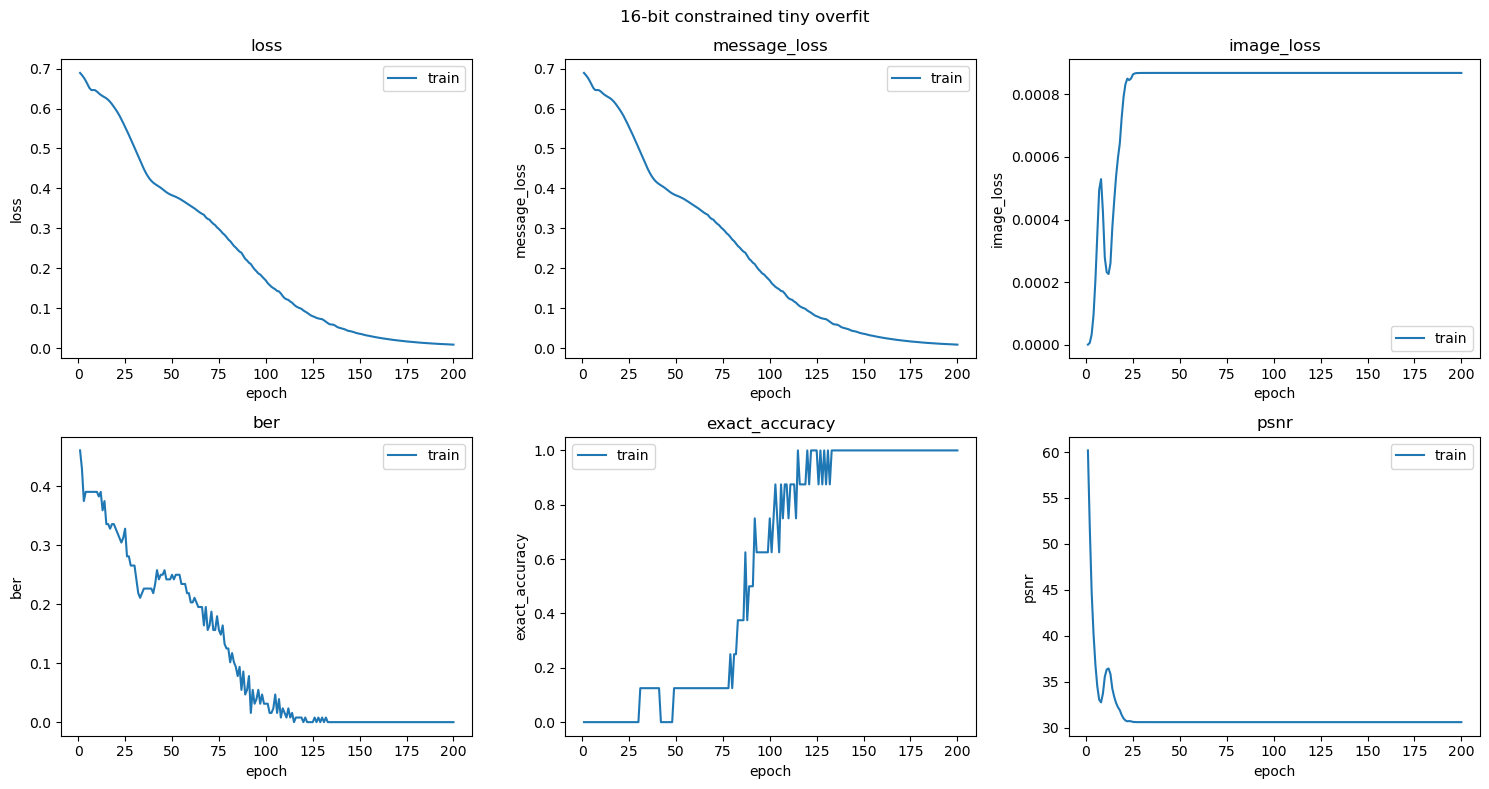

In [ ]:
tiny_16_config = TrainConfig(
    experiment_name="tiny-overfit-16bit-delta-0.03",
    epochs=200,
    batch_size=8,
    message_length=16,
    encoder_channels=(64, 64, 32),
    decoder_channels=(32, 64, 128),
    encoder_max_delta=0.03,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir="../results/checkpoints",
    log_path="../results/logs/tiny-overfit-16bit-delta-0.03.csv",
    attack_configs=None,
    print_every=20,
)

clear_training_log(tiny_16_config.log_path)

tiny_16_messages = torch.randint(0, 2, (len(small_train_loader.dataset), tiny_16_config.message_length), generator=torch.Generator().manual_seed(SEED), dtype=torch.float32)

tiny_16_encoder, tiny_16_decoder, tiny_16_history = fit(
    train_loader=small_train_loader,
    val_loader=small_train_loader,
    config=tiny_16_config,
    fixed_train_messages=tiny_16_messages,
    fixed_val_messages=tiny_16_messages,
)

tiny_16_df = analyze_run(tiny_16_config.log_path, name="16-bit constrained tiny overfit", show_validation=False)

The constrained 16-bit model fully memorizes all eight messages. After 200 epochs, training BER is 0, exact message accuracy is 1 and PSNR is 30.62 dB. The `max_delta=0.03` limit therefore preserves the target image-quality range without preventing the small-set learning check.

### 16-Bit Full-Dataset Baseline

We will now train one clean full-dataset model with the same 16-bit message and pixel-change limit. No image-loss term or noise attack is used: image quality is controlled directly by `max_delta=0.03`.

Epoch 1/20 | train_loss=0.6930 | train_BER=0.4964 | train_exact=0.0000 | val_loss=0.6913 | val_BER=0.4965 | val_exact=0.0000 | val_PSNR=30.66 | 41.5s
Epoch 2/20 | train_loss=0.6859 | train_BER=0.4538 | train_exact=0.0000 | val_loss=0.6817 | val_BER=0.4455 | val_exact=0.0000 | val_PSNR=30.61 | 44.4s
Epoch 3/20 | train_loss=0.6806 | train_BER=0.4428 | train_exact=0.0000 | val_loss=0.6798 | val_BER=0.4454 | val_exact=0.0000 | val_PSNR=30.63 | 45.1s
Epoch 4/20 | train_loss=0.6774 | train_BER=0.4375 | train_exact=0.0000 | val_loss=0.6772 | val_BER=0.4420 | val_exact=0.0000 | val_PSNR=30.58 | 45.1s
Epoch 5/20 | train_loss=0.6748 | train_BER=0.4338 | train_exact=0.0000 | val_loss=0.6722 | val_BER=0.4329 | val_exact=0.0000 | val_PSNR=30.57 | 45.3s
Epoch 6/20 | train_loss=0.6741 | train_BER=0.4422 | train_exact=0.0000 | val_loss=0.6745 | val_BER=0.4511 | val_exact=0.0000 | val_PSNR=30.57 | 45.9s
Epoch 7/20 | train_loss=0.6683 | train_BER=0.4589 | train_exact=0.0000 | val_loss=0.6608 | val_BER=0

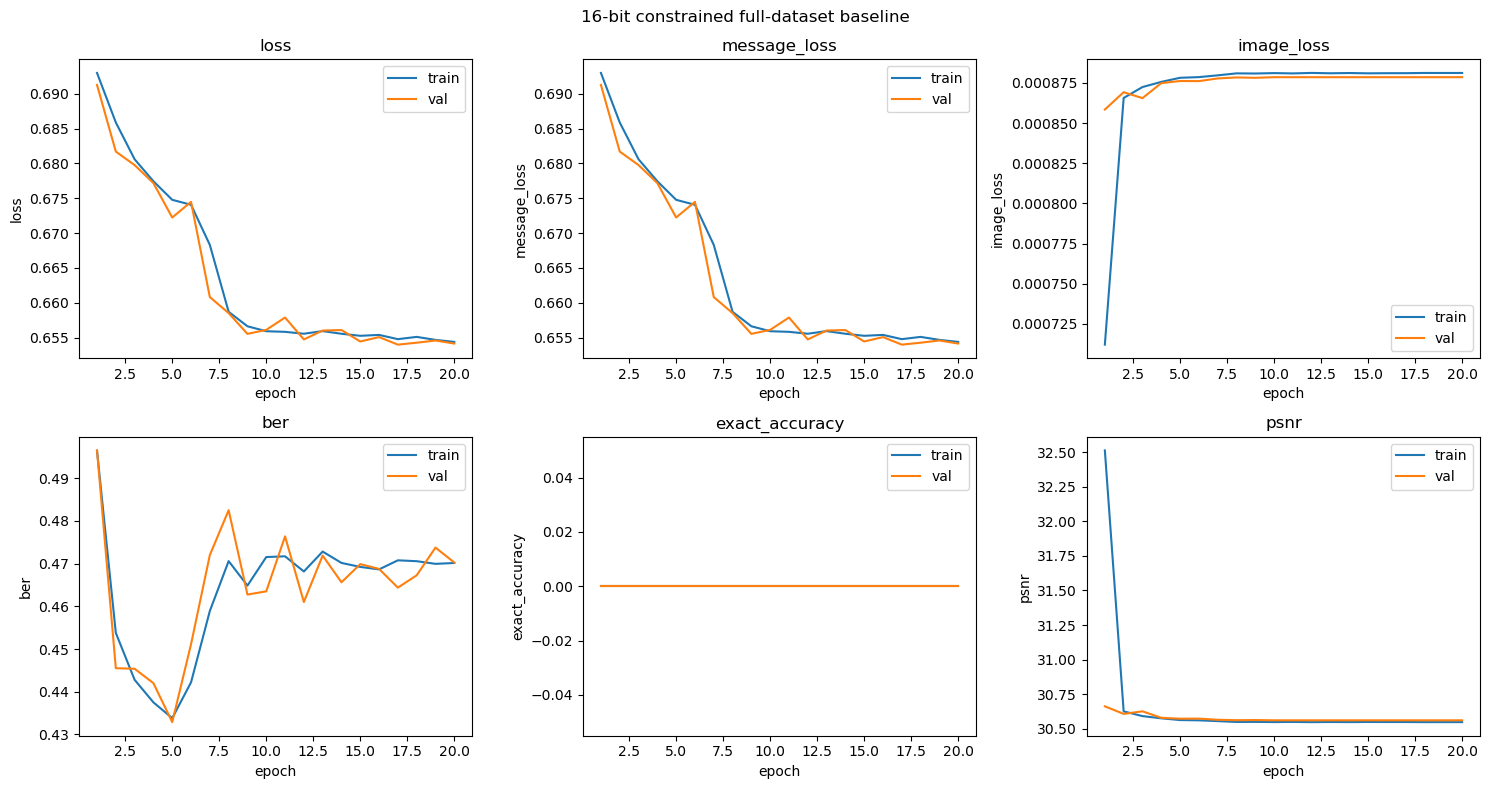

In [ ]:
baseline_16_config = TrainConfig(
    experiment_name="baseline-16bit-delta-0.03",
    epochs=20,
    batch_size=32,
    message_length=16,
    encoder_channels=(64, 64, 32),
    decoder_channels=(32, 64, 128),
    encoder_max_delta=0.03,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir="../results/checkpoints",
    log_path="../results/logs/baseline-16bit-delta-0.03.csv",
    attack_configs=None,
    print_every=1,
)

clear_training_log(baseline_16_config.log_path)

baseline_16_encoder, baseline_16_decoder, baseline_16_history = run_training(data_dir=DATA_DIR, splits_file=SPLITS_FILE, config=baseline_16_config, num_workers=4)

baseline_16_df = analyze_run(baseline_16_config.log_path, name="16-bit constrained full-dataset baseline")

The pixel-change limit works as intended: validation PSNR remains stable at about 30.56 dB. However, validation BER reaches only 0.4644 at the best-loss epoch and exact message accuracy remains 0.

Reducing the message to 16 bits is sufficient for the tiny memorization check, but it does not solve full-dataset message recovery with the current decoder. We will stop here: image loss and noise are not introduced. The next change should target the decoder architecture, especially its max-pooling stages, which can discard the weak distributed watermark signal.

## Average-pooling decoder check

The existing max-pooling decoder keeps only the strongest local activations, which can suppress a weak watermark distributed over the image. We will test average pooling while keeping the 16-bit message, channel counts, pixel-change limit, learning rate and all other settings unchanged.

Epoch 1/200 | train_loss=0.6896 | train_BER=0.4688 | train_exact=0.0000 | 0.2s
Epoch 20/200 | train_loss=0.6109 | train_BER=0.3281 | train_exact=0.0000 | 0.2s
Epoch 40/200 | train_loss=0.4410 | train_BER=0.2266 | train_exact=0.1250 | 0.2s
Epoch 60/200 | train_loss=0.3681 | train_BER=0.2422 | train_exact=0.1250 | 0.2s
Epoch 80/200 | train_loss=0.3125 | train_BER=0.1562 | train_exact=0.2500 | 0.2s
Epoch 100/200 | train_loss=0.2374 | train_BER=0.1016 | train_exact=0.5000 | 0.2s
Epoch 120/200 | train_loss=0.2482 | train_BER=0.1094 | train_exact=0.2500 | 0.2s
Epoch 140/200 | train_loss=0.1788 | train_BER=0.0391 | train_exact=0.5000 | 0.2s
Epoch 160/200 | train_loss=0.1380 | train_BER=0.0234 | train_exact=0.7500 | 0.2s
Epoch 180/200 | train_loss=0.1025 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Epoch 200/200 | train_loss=0.0693 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Training time: 0.7 minutes
Summary for 16-bit average-pooling tiny overfit
----------------------------------------

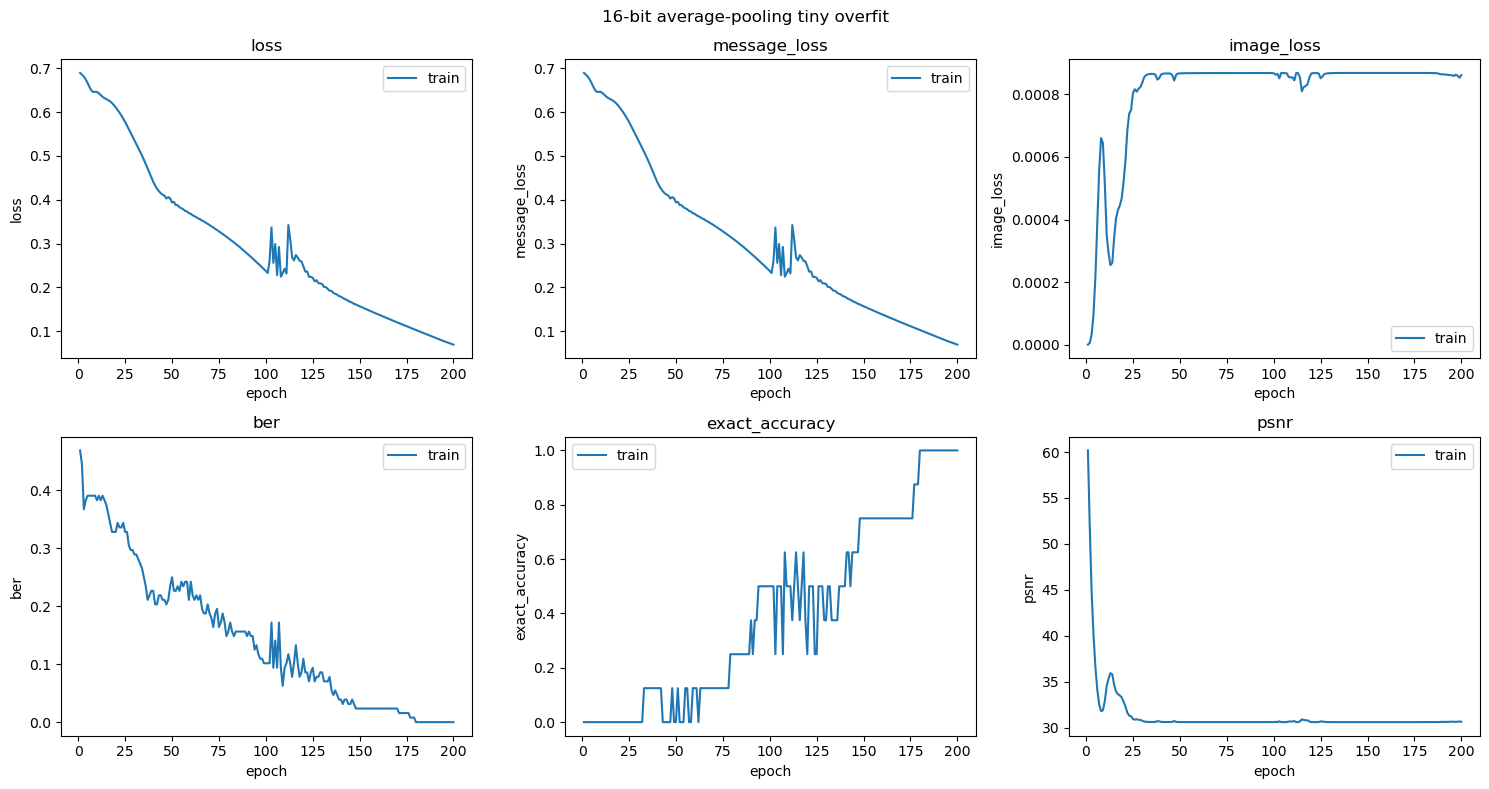

In [ ]:
tiny_16_avg_config = TrainConfig(
    experiment_name="tiny-overfit-16bit-avg-delta-0.03",
    epochs=200,
    batch_size=8,
    message_length=16,
    encoder_channels=(64, 64, 32),
    decoder_channels=(32, 64, 128),
    decoder_pooling="avg",
    encoder_max_delta=0.03,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir="../results/checkpoints",
    log_path="../results/logs/tiny-overfit-16bit-avg-delta-0.03.csv",
    attack_configs=None,
    print_every=20,
)

clear_training_log(tiny_16_avg_config.log_path)

tiny_16_avg_encoder, tiny_16_avg_decoder, tiny_16_avg_history = fit(
    train_loader=small_train_loader,
    val_loader=small_train_loader,
    config=tiny_16_avg_config,
    fixed_train_messages=tiny_16_messages,
    fixed_val_messages=tiny_16_messages,
)

tiny_16_avg_df = analyze_run(tiny_16_avg_config.log_path, name="16-bit average-pooling tiny overfit", show_validation=False)

Epoch 1/20 | train_loss=0.6933 | train_BER=0.4975 | train_exact=0.0000 | val_loss=0.6935 | val_BER=0.5000 | val_exact=0.0000 | val_PSNR=30.73 | 42.0s
Epoch 2/20 | train_loss=0.6929 | train_BER=0.4939 | train_exact=0.0000 | val_loss=0.6927 | val_BER=0.4938 | val_exact=0.0000 | val_PSNR=30.64 | 43.7s
Epoch 3/20 | train_loss=0.6924 | train_BER=0.4893 | train_exact=0.0000 | val_loss=0.6930 | val_BER=0.4889 | val_exact=0.0000 | val_PSNR=30.62 | 44.0s
Epoch 4/20 | train_loss=0.6924 | train_BER=0.4877 | train_exact=0.0000 | val_loss=0.6922 | val_BER=0.4851 | val_exact=0.0000 | val_PSNR=30.59 | 46.3s
Epoch 5/20 | train_loss=0.6925 | train_BER=0.4883 | train_exact=0.0000 | val_loss=0.6923 | val_BER=0.4825 | val_exact=0.0000 | val_PSNR=30.57 | 45.5s
Epoch 6/20 | train_loss=0.6925 | train_BER=0.4905 | train_exact=0.0000 | val_loss=0.6922 | val_BER=0.4880 | val_exact=0.0000 | val_PSNR=30.60 | 45.8s
Epoch 7/20 | train_loss=0.6920 | train_BER=0.4851 | train_exact=0.0000 | val_loss=0.6919 | val_BER=0

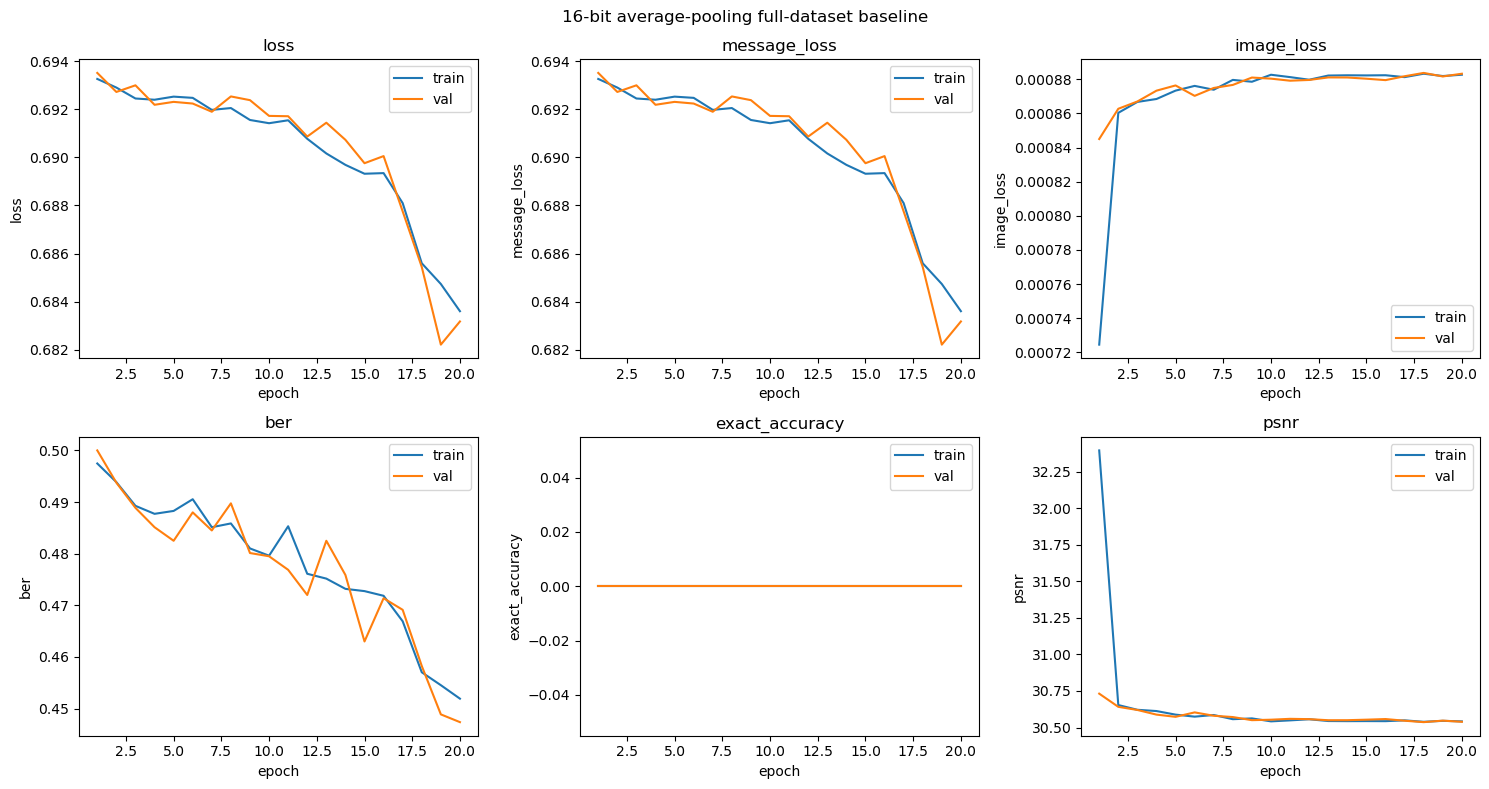

In [ ]:
baseline_16_avg_config = TrainConfig(
    experiment_name="baseline-16bit-avg-delta-0.03",
    epochs=20,
    batch_size=32,
    message_length=16,
    encoder_channels=(64, 64, 32),
    decoder_channels=(32, 64, 128),
    decoder_pooling="avg",
    encoder_max_delta=0.03,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir="../results/checkpoints",
    log_path="../results/logs/baseline-16bit-avg-delta-0.03.csv",
    attack_configs=None,
    print_every=1,
)

clear_training_log(baseline_16_avg_config.log_path)

baseline_16_avg_encoder, baseline_16_avg_decoder, baseline_16_avg_history = run_training(
    data_dir=DATA_DIR,
    splits_file=SPLITS_FILE,
    config=baseline_16_avg_config,
    num_workers=4,
)

baseline_16_avg_df = analyze_run(baseline_16_avg_config.log_path, name="16-bit average-pooling full-dataset baseline")

Average pooling slightly improves full-dataset recovery compared with max pooling: the best validation BER is 0.4489 instead of 0.4644, while PSNR remains about 30.55 dB. This is still far above the target BER of 0.2, and exact message accuracy remains 0.

## Overview

We will summarize all previous experiments on the original model. For each experiment, `selected_ber` and `selected_psnr` come from the epoch with minimum validation loss. `minimum_ber` records the lowest validation BER observed anywhere in the same run, which may occur at a different epoch.

In [ ]:
experiment_logs = [
    ("Message-only (32 bit)", "full-message-only.csv"),
    ("Image weight 0.03", "baseline-weight-0.03.csv"),
    ("Image weight 0.10", "baseline-weight-0.1.csv"),
    ("Image weight 0.30", "baseline-weight-0.3.csv"),
    ("Small model (40 epochs)", "baseline-small.csv"),
    ("Wide model", "baseline-wide.csv"),
    ("16 bit, max pool, delta 0.03", "baseline-16bit-delta-0.03.csv"),
    ("16 bit, avg pool, delta 0.03", "baseline-16bit-avg-delta-0.03.csv"),
]


def summarize_experiment(experiment, file_name):
    run = pd.read_csv(PROJECT_ROOT / "results" / "logs" / file_name)
    selected = run.loc[run["val_loss"].idxmin()]
    minimum_ber = run.loc[run["val_ber"].idxmin()]

    return {
        "experiment": experiment,
        "selected_epoch": int(selected["epoch"]),
        "selected_ber": selected["val_ber"],
        "minimum_ber": minimum_ber["val_ber"],
        "minimum_ber_epoch": int(minimum_ber["epoch"]),
        "selected_psnr": selected["val_psnr"],
        "exact_accuracy": selected["val_exact_accuracy"],
    }


baseline_results = pd.DataFrame(summarize_experiment(experiment, file_name) for experiment, file_name in experiment_logs)

baseline_results.round(4)

,experiment,selected_epoch,selected_ber,minimum_ber,minimum_ber_epoch,selected_psnr,exact_accuracy
0,Message-only (32 bit),38,0.3709,0.3657,40,7.4393,0.0
1,Image weight 0.03,20,0.4084,0.4077,5,11.1468,0.0
2,Image weight 0.10,20,0.4381,0.4276,9,15.2725,0.0
3,Image weight 0.30,18,0.4314,0.4314,18,19.1571,0.0
4,Small model (40 epochs),40,0.4390,0.4281,14,20.9463,0.0
5,Wide model,4,0.4914,0.4914,4,66.4783,0.0
6,"16 bit, max pool, delta 0.03",17,0.4644,0.4329,5,30.5625,0.0
7,"16 bit, avg pool, delta 0.03",19,0.4489,0.4474,20,30.5471,0.0


### Visualization

The left plot shows the **BER-PSNR** trade-off for the selected checkpoints. The ideal point would be near the bottom-right corner: low BER and high PSNR.

The right plot loads complete local CSV logs for the bounded 16-bit experiments.

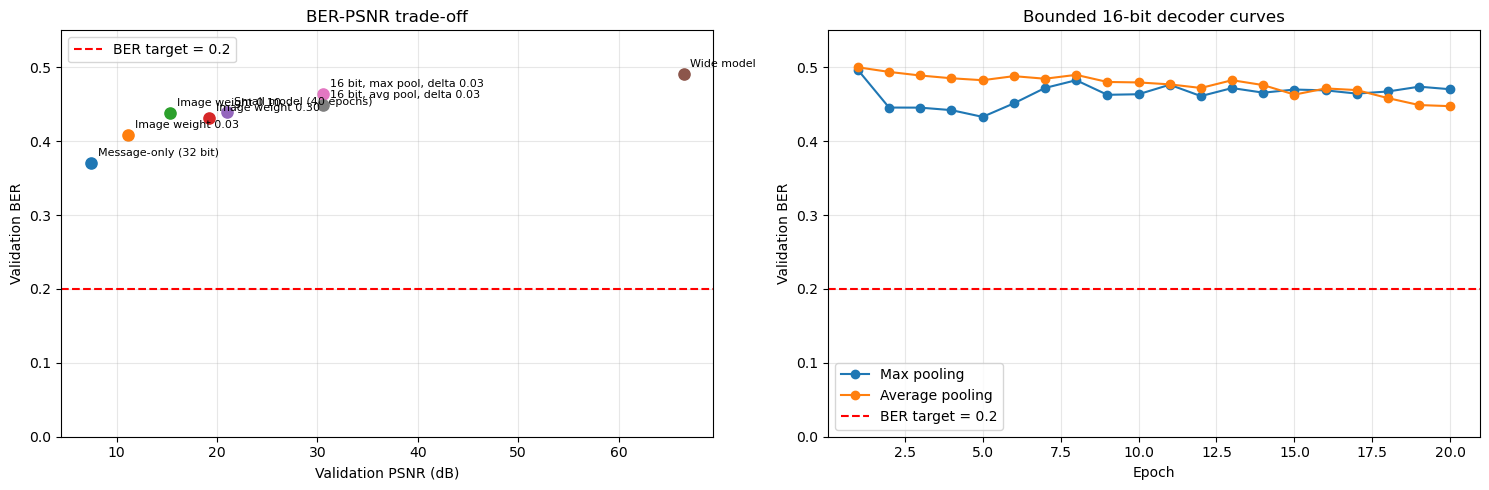

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for _, row in baseline_results.iterrows():
    axes[0].scatter(row["selected_psnr"], row["selected_ber"], s=65)
    axes[0].annotate(
        row["experiment"],
        (row["selected_psnr"], row["selected_ber"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

axes[0].axhline(0.2, color="red", linestyle="--", label="BER target = 0.2")
axes[0].set_xlabel("Validation PSNR (dB)")
axes[0].set_ylabel("Validation BER")
axes[0].set_title("BER-PSNR trade-off")
axes[0].set_ylim(0.0, 0.55)
axes[0].grid(alpha=0.3)
axes[0].legend()

curve_specs = [
    ("baseline-16bit-delta-0.03.csv", "Max pooling"),
    ("baseline-16bit-avg-delta-0.03.csv", "Average pooling"),
]
curves_found = False

for file_name, label in curve_specs:
    log_path = PROJECT_ROOT / "results" / "logs" / file_name
    if log_path.exists():
        curve = pd.read_csv(log_path)
        axes[1].plot(curve["epoch"], curve["val_ber"], marker="o", label=label)
        curves_found = True

axes[1].axhline(0.2, color="red", linestyle="--", label="BER target = 0.2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation BER")
axes[1].set_title("Bounded 16-bit decoder curves")
axes[1].set_ylim(0.0, 0.55)
axes[1].grid(alpha=0.3)

if curves_found:
    axes[1].legend()
else:
    axes[1].text(
        0.5,
        0.5,
        "Detailed local CSV logs are not available.",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
    )

fig.tight_layout()
plt.show()

### Examples

To see what the model actually does to the images, we will display four validation images with the largest number of incorrect bits in the first batch. For each image, we will show the original, its watermarked version, the expected message and the prediction. This checkpoint belongs to the 16-bit max-pooling model with `max_delta=0.03`.

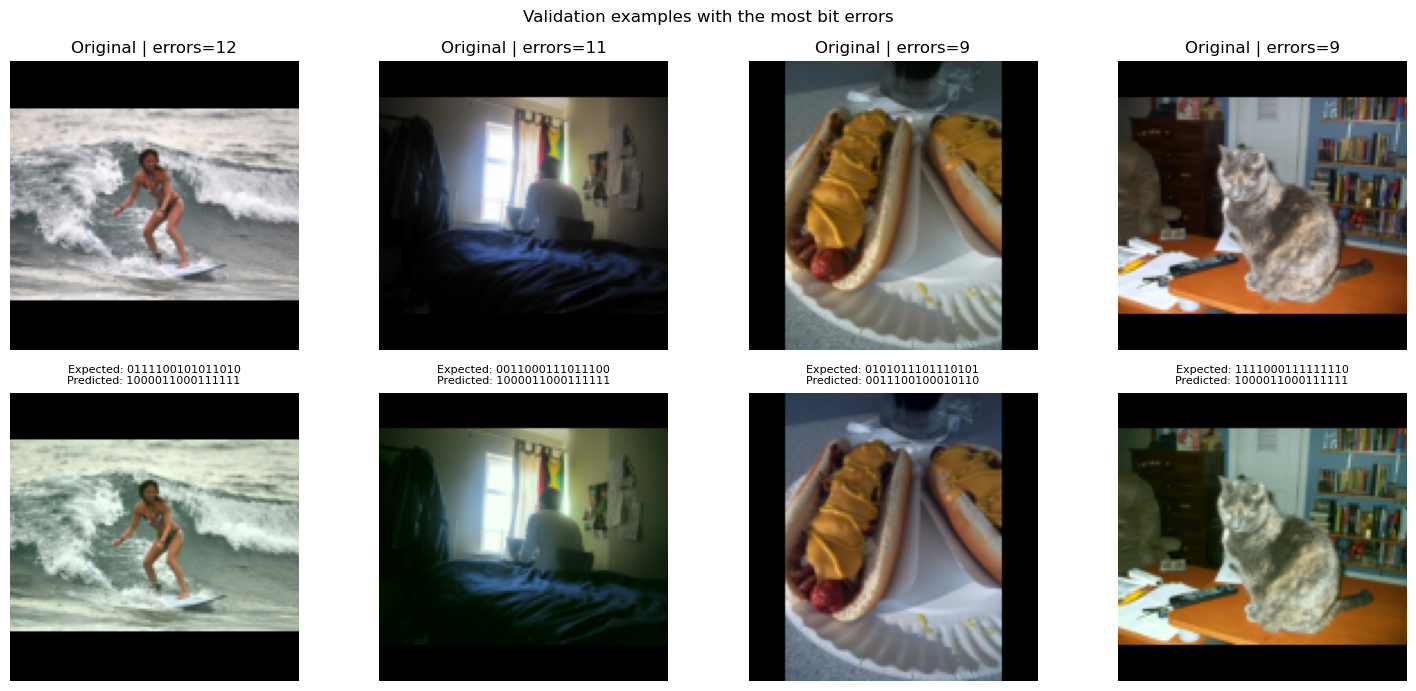

In [ ]:
checkpoint_path = (
    PROJECT_ROOT
    / "results"
    / "checkpoints"
    / "baseline-16bit-delta-0.03"
    / "best_model.pt"
)

if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=EVALUATION_DEVICE, weights_only=False)
    encoder = OriginalWatermarkEncoder().to(EVALUATION_DEVICE)
    decoder = OriginalWatermarkDecoder().to(EVALUATION_DEVICE)
    encoder.load_state_dict(checkpoint["encoder_state_dict"])
    decoder.load_state_dict(checkpoint["decoder_state_dict"])
    encoder.eval()
    decoder.eval()

    example_images, example_masks = next(iter(val_loader))
    example_images = example_images.to(EVALUATION_DEVICE)
    example_masks = example_masks.to(EVALUATION_DEVICE)
    example_messages = torch.randint(0, 2, (len(example_images), 16), generator=torch.Generator().manual_seed(SEED), dtype=torch.float32,).to(EVALUATION_DEVICE)

    with torch.no_grad():
        example_watermarked = encoder(example_images, example_messages, example_masks)
        example_logits = decoder(example_watermarked)
        predicted_messages = (example_logits >= 0).to(torch.int64)

    bit_errors = (predicted_messages != example_messages.to(torch.int64)).sum(dim=1)
    worst_indices = torch.topk(bit_errors, k=4).indices

    fig, axes = plt.subplots(2, 4, figsize=(15, 7))
    for column, index in enumerate(worst_indices.tolist()):
        original = example_images[index].permute(1, 2, 0).cpu()
        marked = example_watermarked[index].permute(1, 2, 0).cpu()
        expected = "".join(str(bit) for bit in example_messages[index].int().tolist())
        predicted = "".join(str(bit) for bit in predicted_messages[index].tolist())

        axes[0, column].imshow(original)
        axes[0, column].set_title(f"Original | errors={bit_errors[index].item()}")
        axes[1, column].imshow(marked)
        axes[1, column].set_title(f"Expected: {expected}\nPredicted: {predicted}", fontsize=8)

        axes[0, column].axis("off")
        axes[1, column].axis("off")

    fig.suptitle("Validation examples with the most bit errors")
    fig.tight_layout()
    plt.show()
else:
    print(
        "Historical checkpoint is not available locally. "
        "The embedded metrics above remain reproducible without it."
    )

### Conclusion

The experiments provide three clear observations:

1. The message-only model lowers BER, but at PSNR `7.44 dB`, meaning that it learns the message through an unacceptably large image distortion.
2. When image quality becomes acceptable, full-dataset BER remains approximately `0.4-0.5`, while exact message accuracy remains zero.
3. Increasing channel count, training the smaller model for more epochs and replacing max pooling with average pooling do not solve the problem.

The most likely architectural explanation is that the message is introduced before visual features are extracted, while the shallow decoder discards the weak spatially distributed signal through three pooling operations. Small set BER of zero shows that the implementation and gradients work. The full-dataset failure is probably the result of a generalization problem in the architecture under a subtle watermark constraint, rather than a broken training pipeline. All this suggests that we need to use a more complex network.